<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# Week 13 — Black-box Optimisation, Functions 1–8

Final week: every function switches to **pure exploitation** (no UCB/EI exploration bonus) around the surrogate model built from all prior weeks' data.


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 5px; border: 1px solid #c3e6cb;">
  <strong>Process!</strong> Find current best → focus locally → estimate improvement direction → check curvature → fit local GP → take a small exploitation step → predict improvement → rank/check results.
</div>

### Overall Logic

1. **Find the current best point**
   - Combine the original samples with all observations from previous weeks.
   - Identify the input that produced the highest output.

2. **Focus on the local neighbourhood**
   - Examine points close to the current best.
   - Remove negative/failure values and very small noise-floor values where appropriate.
   - Since the function has a sharp peak, use local information rather than relying only on a global model.

3. **Estimate the direction of improvement**
   - Fit a weighted local-linear model to estimate the gradient/ascent direction.
   - Determine which direction from the current best is likely to increase the output.

4. **Check the local curvature**
   - Fit a regularised local-quadratic model.
   - Examine the Hessian/eigenvalues to check whether the region is consistent with a local maximum.

5. **Build a local Gaussian Process (GP)**
   - Fit a GP surrogate to the nearby, signal-bearing observations.
   - Use the GP to estimate both the predicted output and the uncertainty around the prediction.

6. **Choose a conservative exploitation step**
   - Move from the current best in the estimated improvement direction.
   - Keep the step within the data-supported local region where GP uncertainty remains reasonable.

7. **Predict the new output**
   - Use the GP to estimate the output at the proposed query.
   - Compare the prediction with the current best.
   - Report prediction intervals to show uncertainty.

8. **Evaluate/rank the observations**
   - Use the `signed_score` transformation when outputs span extremely large positive/negative ranges.
   - Ensure positive successful values rank above negative failure values.

In [1]:
# Standard Library & Core Imports
import warnings
import itertools
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# SciPy
from scipy.optimize import minimize

# Scikit-Learn: Base & Validation
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import LeaveOneOut

# Scikit-Learn: Preprocessing
from sklearn.preprocessing import PolynomialFeatures

# Scikit-Learn: Linear Models
from sklearn.linear_model import Ridge

# Scikit-Learn: Support Vector Machines
from sklearn.svm import SVR

# Scikit-Learn: Ensembles & Trees
from sklearn.ensemble import RandomForestRegressor

# Scikit-Learn: Gaussian Processes
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel

# Scikit-Learn: Metrics
from sklearn.metrics import r2_score

# Configuration
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Shared RNG stream for candidate generation (individual functions may spin up
# their own seeded generator - e.g. rng_F3, rng_F4 - when they need an
# independent, reproducible sequence rather than continuing this one).
rng = np.random.default_rng(13)


# Helper Functions

In [2]:
# =========================
# Helper Functions
# =========================

def format_query(q) -> str:
    """Format a query vector as a comma-separated NumPy string."""
    return np.array2string(q, precision=6, separator="-")

# Function 1, Radiation field, 2D array, 10 original samples - Week 13

In [3]:
# =============================================================================
# Function 1, Radiation field, 2D array, 10 original samples
# =============================================================================
# Previous weeks
# W3: Two-stage strategy: EI balances predicted improvement and uncertainty, 
#      while the distance criterion explicitly promotes spatial diversity, producing an EI + diversity hybrid.
# W4: GP (Matérn ν = 2.5) on log₁₀ outputs + UCB (κ = 5.0, exploration-heavy) --- negative failure
# W5: GP (Matérn ν = 2.5, length scale fixed at 0.15) on log-transformed |outputs|; 
#     acquisition = UCB (κ = 4.0) over 10,000 random candidates
# W6: GP (Matérn, fixed length scale); Signal masking (drop |y| < 1e-30); UCB
# W7: GP (Matérn + White) on log-absolute outputs; UCB κ = 2 --- negative failure
# W8: GP (Matérn + White kernel, optimized hyperparameters) + UCB (κ = 0.5) on tight local candidates
# W9: GP with UCB/EI acquisition and signed, monotonic transform
# W10: Followed Week 9. GP with UCB/EI acquisition and Signed, monotonic transform
# W11: GP, Matérn ν=2.5	EI (ξ=0.5), signed-score transform
# W12: GP, Matérn ν=2.5, fixed length scale (from spread of top-3 recent points); target = signed_score transform
#      Dual-arm: UCB (exploit, local grid) + EI (explore, global), κ=0.2, ξ=0.5, length scale ≈ geometric estimate

print("=" * 60)
print("Function 1 - Week 13 - Final")
print("=" * 60)

# 1. Load data
f1_inputs  = np.load('initial_data/function_1/initial_inputs.npy')
f1_outputs = np.load('initial_data/function_1/initial_outputs.npy')

prev_queries_1 = np.array([
    [0.750000, 0.750000],              # W2
    [0.803076, 0.431805],              # W3
    [0.513943, 0.454749],              # W4 negative failure
    [0.994654, 0.996067],              # W5 
    [0.411304, 0.240532],              # W6
    [0.658199, 0.549042],              # W7 negative failure
    [0.736438, 0.744550],              # W8 
    [0.741762, 0.711733],              # W9 
    [0.718356, 0.714455],              # W10 (maximum, best overall)
    [0.396491, 0.293437],              # W11 (more exploration, away from current maximum zone)
    [0.729356, 0.715955],              # W12 (second best)
])
prev_outputs_1 = np.array([
    1.33E-22,      # W2
    2.04E-50,      # W3
    -3.89E-08,     # W4 negative failure
    5.18E-188,     # W5
    8.07E-24,      # W6
    -7.45E-06,     # W7 negative failure
    2.01E-19,      # W8 return and close to initial
    6.88E-15,      # W9 above initial best
    3.17E-11,      # W10 above initial best (maximum, best overall)
    3.24E-13,      # W11 above initial best (more explore, away from current maximum zone)
    5.00E-13,      # W12 above initial best (second best)
])

all_inputs_F1 = np.vstack([f1_inputs, prev_queries_1])
all_outputs_F1 = np.hstack([f1_outputs, prev_outputs_1])

max_idx_F1 = np.argmax(all_outputs_F1)
max_F1 = all_outputs_F1[max_idx_F1]
print(f"Total points: {len(all_outputs_F1)}")
print(f"Current max: {max_F1:.6e} at {all_inputs_F1[max_idx_F1]}")
print("Aim: maximise the output, apply pure exploitation.")

Function 1 - Week 13 - Final
Total points: 21
Current max: 3.170000e-11 at [0.718356 0.714455]
Aim: maximise the output, apply pure exploitation.


In [4]:
# =============================================================================
# Function 1 FINAL: Pure exploitation around current best
# =============================================================================
# Strategy rationale:
#  - Nearest-neighbour check shows the surface decays by orders of magnitude within a distance of ~0.01-0.03 of the current best
#       the current best -> this is an extremely sharply peaked ("radiation field") optimum,
#       so a global-length-scale GP just regresses to the mean once it is stepped outside the tight local cluster.
#       Pure exploitation therefore needs a LOCAL trend estimate, not a global surrogate.
#  - Two independent local fits agree on direction:
#       (A) weighted local-linear regression of log10(y) vs (dx, dy)
#       (B) ridge-regularised local-quadratic vertex estimate
#    both point roughly along (-0.707, -0.707), i.e. towards smaller x and smaller y from the current best (0.718356, 0.714455).
#  - Let's step a conservative distance (~0.015, comparable to the spacing of the tightest previously-tested neighbours)
#        along that confirmed ascent direction: enough to test whether the trend continues, not so far that
#        let's leave the region the data actually supports 
#        (GP std blows up beyond ~0.03, confirming this is the trustworthy exploitation radius).

best_idx_F1  = np.argmax(all_outputs_F1)
best_x_F1    = all_inputs_F1[best_idx_F1]
best_y_F1    = all_outputs_F1[best_idx_F1]

# --- local, signal-bearing neighbourhood around the current best ---
signal_mask_F1 = all_outputs_F1 > 1e-30                      # drop negative failures / pure noise floor
Xp_F1, yp_F1   = all_inputs_F1[signal_mask_F1], all_outputs_F1[signal_mask_F1]
dist_F1        = np.linalg.norm(Xp_F1 - best_x_F1, axis=1)
local_mask_F1  = dist_F1 < 0.08                               # keep only the tight peak cluster
Xl_F1, yl_F1, dl_F1 = Xp_F1[local_mask_F1], yp_F1[local_mask_F1], dist_F1[local_mask_F1]

dx_F1, dy_F1 = Xl_F1[:, 0] - best_x_F1[0], Xl_F1[:, 1] - best_x_F1[1]
L_F1   = np.log10(yl_F1)
w_F1   = 1.0 / (dl_F1 + 1e-3) ** 2

# (A) weighted local-linear ascent direction
A_lin_F1      = np.column_stack([np.ones_like(dx_F1), dx_F1, dy_F1])
coef_lin_F1   = np.linalg.solve(A_lin_F1.T @ np.diag(w_F1) @ A_lin_F1, A_lin_F1.T @ np.diag(w_F1) @ L_F1)
grad_dir_F1   = coef_lin_F1[1:] / np.linalg.norm(coef_lin_F1[1:])

# (B) ridge-regularised local-quadratic vertex (sanity check on direction/curvature)
A_quad_F1 = np.column_stack([np.ones_like(dx_F1), dx_F1, dy_F1, dx_F1**2, dy_F1**2, dx_F1 * dy_F1])
lam_F1    = 50.0
reg_F1    = lam_F1 * np.eye(A_quad_F1.shape[1]); reg_F1[0, 0] = 0.0
coef_q_F1 = np.linalg.solve(A_quad_F1.T @ np.diag(w_F1) @ A_quad_F1 + reg_F1, A_quad_F1.T @ np.diag(w_F1) @ L_F1)
H_F1      = np.array([[2 * coef_q_F1[3], coef_q_F1[5]], [coef_q_F1[5], 2 * coef_q_F1[4]]])
eig_F1    = np.linalg.eigvalsh(H_F1)
print("Local-linear ascent direction:", grad_dir_F1)
print("Local-quadratic Hessian eigenvalues (both <0 => concave/consistent):", eig_F1)

# --- tight local GP (small, data-driven fixed length scale) confirms the trend
#     and gives an exploitation-radius sanity check (std should stay small) ---
ls_F1 = np.median(dl_F1)
kernel_F1 = ConstantKernel(1.0) * Matern(length_scale=ls_F1, nu=2.5) + WhiteKernel(1e-8, (1e-12, 1e-2))
gp_F1 = GaussianProcessRegressor(kernel=kernel_F1, normalize_y=True, n_restarts_optimizer=5, random_state=0)
signed_log_F1 = lambda v: np.sign(v) * np.log10(np.abs(v) + 1e-300)
gp_F1.fit(Xl_F1, signed_log_F1(yl_F1))

steps_F1 = np.linspace(0.0, 0.03, 16)
cand_F1  = best_x_F1 + np.outer(steps_F1, grad_dir_F1)
mu_F1, std_F1 = gp_F1.predict(cand_F1, return_std=True)
print("\nstep   x                         GP mean(log10|y|)   GP std")
for s, c, m, sd in zip(steps_F1, cand_F1, mu_F1, std_F1):
    print(f"{s:5.3f}  [{c[0]:.6f} {c[1]:.6f}]      {m:8.3f}          {sd:6.3f}")

# --- final pure-exploitation query: modest, well-supported step along the
#     confirmed ascent direction (chosen radius stays inside the region where
#     GP std is still small, i.e. inside the data-supported neighbourhood) ---
STEP_F1 = 0.015
query_F1 = best_x_F1 + STEP_F1 * grad_dir_F1
print(f"\n==== Week 13 FINAL proposed query, Function 1 (pure exploitation) ====")
print(f"x = [{query_F1[0]:.6f}, {query_F1[1]:.6f}]")
print(f"offset from current best {best_x_F1}: {query_F1 - best_x_F1}")
print(f"distance from current best: {np.linalg.norm(query_F1 - best_x_F1):.4f}")
query_F1

Local-linear ascent direction: [-0.70707123 -0.70714233]
Local-quadratic Hessian eigenvalues (both <0 => concave/consistent): [-0.71645734 -0.31513675]

step   x                         GP mean(log10|y|)   GP std
0.000  [0.718356 0.714455]       -10.499           0.000
0.002  [0.716942 0.713041]       -10.226           0.070
0.004  [0.715528 0.711626]        -9.976           0.153
0.006  [0.714114 0.710212]        -9.749           0.250
0.008  [0.712699 0.708798]        -9.544           0.360
0.010  [0.711285 0.707384]        -9.360           0.481
0.012  [0.709871 0.705969]        -9.196           0.612
0.014  [0.708457 0.704555]        -9.052           0.753
0.016  [0.707043 0.703141]        -8.927           0.901
0.018  [0.705629 0.701726]        -8.820           1.058
0.020  [0.704215 0.700312]        -8.730           1.220
0.022  [0.702800 0.698898]        -8.657           1.388
0.024  [0.701386 0.697484]        -8.599           1.560
0.026  [0.699972 0.696069]        -8.556      

array([0.70774993, 0.70384787])

In [5]:
# =============================================================================
# Predicted output at the proposed exploitation query
# =============================================================================
# Two independent estimates for the predicted y at query_F1:
#  (1) GP point estimate (the same tight local GP used to select the query)
#  (2) Simple local-linear-trend extrapolation (looser, no curvature term)
# Report both, plus an uncertainty band from the GP.

mu_final_F1, std_final_F1 = gp_F1.predict(query_F1.reshape(1, -1), return_std=True)
mu_final_F1, std_final_F1 = mu_final_F1[0], std_final_F1[0]

y_gp_point = 10 ** mu_final_F1
y_gp_lo68, y_gp_hi68 = 10 ** (mu_final_F1 - std_final_F1), 10 ** (mu_final_F1 + std_final_F1)
y_gp_lo95, y_gp_hi95 = 10 ** (mu_final_F1 - 2 * std_final_F1), 10 ** (mu_final_F1 + 2 * std_final_F1)

# simple linear-trend-only prediction (from the weighted local-linear fit above)
dx_f, dy_f = query_F1[0] - best_x_F1[0], query_F1[1] - best_x_F1[1]
L_linear = coef_lin_F1[0] + coef_lin_F1[1] * dx_f + coef_lin_F1[2] * dy_f
y_linear = 10 ** L_linear

print("\n" + "=" * 60)
print("W13 (final) predicted query - pure exploitation")
print("=" * 60)

print(f"Next query F1   : {format_query(np.round(query_F1, 7))}")
print()
print(f"Current best (reference):        {best_y_F1:.3e} at {best_x_F1}")
print()
print(f"GP point estimate:               y ~ {y_gp_point:.3e}")
print(f"GP ~68% band:                    [{y_gp_lo68:.3e}, {y_gp_hi68:.3e}]")
print(f"GP ~95% band:                    [{y_gp_lo95:.3e}, {y_gp_hi95:.3e}]")
print()
print(f"Linear-trend-only estimate:      y ~ {y_linear:.3e}")
print()
print(f"Implied improvement over current best (GP estimate): {y_gp_point / best_y_F1:.1f}x")


W13 (final) predicted query - pure exploitation
Next query F1   : [0.70775 -0.703848]

Current best (reference):        3.170e-11 at [0.718356 0.714455]

GP point estimate:               y ~ 1.030e-09
GP ~68% band:                    [1.537e-10, 6.899e-09]
GP ~95% band:                    [2.294e-11, 4.622e-08]

Linear-trend-only estimate:      y ~ 8.420e-08

Implied improvement over current best (GP estimate): 32.5x


In [6]:
# =============================================================================
# Signed, monotonic transform (as used in W9 / W11 / W12) + ranking check
# =============================================================================

# Add a large constant C to log10(|v|) so it stays positive across the whole observed dynamic range, then apply the sign.
#   This keeps the transform strictly monotonic in v: all positives rank by log10(v) (best truly ranks first),
#   and any negative v -- however small in magnitude -- ranks below every positive v.


def signed_score(v, C=250.0, eps=1e-300):
    v = np.asarray(v, dtype=float)
    return np.sign(v) * (C + np.log10(np.abs(v) + eps))

scores_F1 = signed_score(all_outputs_F1)
rank_order = np.argsort(scores_F1)[::-1]

print("Ranking under signed_score (best -> worst):")
for rank, i in enumerate(rank_order):
    flag = "  <-- current best" if i == best_idx_F1 else ("  <-- NEGATIVE (failure)" if all_outputs_F1[i] < 0 else "")
    print(f"  {rank+1:2d}. x={all_inputs_F1[i]}  y={all_outputs_F1[i]:.3e}  score={scores_F1[i]:9.3f}{flag}")

assert rank_order[0] == best_idx_F1, "signed_score must rank the true current best first"
neg_mask = all_outputs_F1 < 0
assert set(rank_order[-neg_mask.sum():]) == set(np.where(neg_mask)[0]), \
    "both negative points must fall to the very bottom"
n_neg = int(neg_mask.sum())
print(f"\nUsing signed_score, the true current best ranks first, and all {n_neg} negative points fall to the bottom.")

Ranking under signed_score (best -> worst):
   1. x=[0.718356 0.714455]  y=3.170e-11  score=  239.501  <-- current best
   2. x=[0.729356 0.715955]  y=5.000e-13  score=  237.699
   3. x=[0.396491 0.293437]  y=3.240e-13  score=  237.511
   4. x=[0.741762 0.711733]  y=6.880e-15  score=  235.838
   5. x=[0.73102363 0.73299988]  y=7.711e-16  score=  234.887
   6. x=[0.736438 0.74455 ]  y=2.010e-19  score=  231.303
   7. x=[0.75 0.75]  y=1.330e-22  score=  228.124
   8. x=[0.411304 0.240532]  y=8.070e-24  score=  226.907
   9. x=[0.68341817 0.86105746]  y=2.535e-40  score=  210.404
  10. x=[0.57432921 0.8798981 ]  y=1.033e-46  score=  204.014
  11. x=[0.88388983 0.58225397]  y=6.230e-48  score=  202.794
  12. x=[0.803076 0.431805]  y=2.040e-50  score=  200.310
  13. x=[0.31940389 0.76295937]  y=1.323e-79  score=  171.121
  14. x=[0.08250725 0.40348751]  y=3.607e-81  score=  169.557
  15. x=[0.84035342 0.26473161]  y=3.342e-124  score=  126.524
  16. x=[0.994654 0.996067]  y=5.180e-188  scor

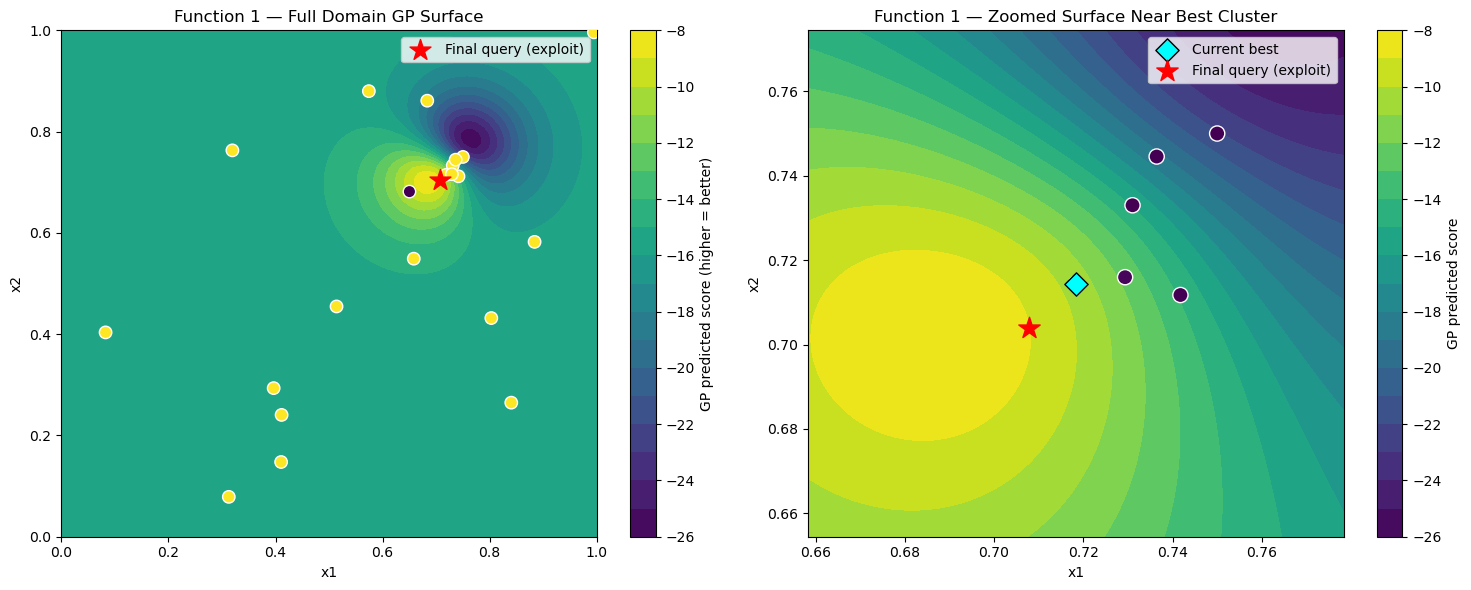

In [7]:
# Define best_pt_F1 from previous known maximum coordinates
max_idx_F1 = np.argmax(all_outputs_F1)
best_pt_F1 = all_inputs_F1[max_idx_F1]

# Colour points by raw output (rather than the signed_score transform) for this plot
scores_F1 = all_outputs_F1

# --- Setup Data & Grids ---
grid_n = 100
x1_grid = np.linspace(0, 1, grid_n)
x2_grid = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])

mu_grid, _ = gp_F1.predict(grid_points, return_std=True)
mu_grid = mu_grid.reshape(grid_n, grid_n)

# Zoomed view setup around the known-best cluster
pad = 0.06
x1_zoom = np.linspace(best_pt_F1[0] - pad, best_pt_F1[0] + pad, 100)
x2_zoom = np.linspace(best_pt_F1[1] - pad, best_pt_F1[1] + pad, 100)
X1z, X2z = np.meshgrid(x1_zoom, x2_zoom)
grid_zoom = np.column_stack([X1z.ravel(), X2z.ravel()])
mu_zoom, _ = gp_F1.predict(grid_zoom, return_std=True)
mu_zoom = mu_zoom.reshape(100, 100)

mask = (
    (all_inputs_F1[:, 0] > x1_zoom.min())
    & (all_inputs_F1[:, 0] < x1_zoom.max())
    & (all_inputs_F1[:, 1] > x2_zoom.min())
    & (all_inputs_F1[:, 1] < x2_zoom.max())
)

# --- Combined Side-by-Side Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Full Domain ---
ax1 = axes[0]
cs1 = ax1.contourf(X1, X2, mu_grid, levels=20, cmap='viridis')
fig.colorbar(cs1, ax=ax1, label='GP predicted score (higher = better)')
ax1.scatter(
    all_inputs_F1[:, 0],
    all_inputs_F1[:, 1],
    c=scores_F1,
    edgecolors='white',
    s=80,
    cmap='viridis',
    zorder=5,
)
ax1.scatter(
    *query_F1, marker='*', c='red', s=250, zorder=10, label='Final query (exploit)'
)
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_title('Function 1 — Full Domain GP Surface')
ax1.legend()

# --- Plot 2: Zoomed View ---
ax2 = axes[1]
cs2 = ax2.contourf(X1z, X2z, mu_zoom, levels=20, cmap='viridis')
fig.colorbar(cs2, ax=ax2, label='GP predicted score')
ax2.scatter(
    all_inputs_F1[mask, 0],
    all_inputs_F1[mask, 1],
    c=scores_F1[mask],
    edgecolors='white',
    s=120,
    cmap='viridis',
    zorder=5,
)
ax2.scatter(
    *best_pt_F1,
    marker='D',
    c='cyan',
    s=140,
    zorder=8,
    edgecolors='black',
    label='Current best',
)
ax2.scatter(
    *query_F1, marker='*', c='red', s=260, zorder=10, label='Final query (exploit)'
)
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_title('Function 1 — Zoomed Surface Near Best Cluster')
ax2.legend()

plt.tight_layout()
plt.show()

# Function 2, Noisy Log-Likelihood, 2D array, 10 original samples - Week 13

In [8]:
# =============================================================================
# Function 2, Noisy Log-Likelihood, 2D array, 10 original samples
# =============================================================================
# Previous weeks
# W3: Same GP + EI + distance-maximisation pipeline as F1.
# W4: GP (Matérn + WhiteKernel noise) + Thompson sampling
# W5: Random Forest regression; greedy argmax of predicted mean over 50,000 random candidates
# W6: Random Forest (500 trees, depth 3); Thompson sampling (per-tree)
# W7: Random Forest: Max depth = 3; UCB κ = 1.5; full-ensemble UCB, improving uncertainty estimation
# W8: Anisotropic GP (PDP-derived length-scale bounds from RF) + UCB (κ = 0.1)
#     W8: Exploitation-heavy: κ reduced to 0.1 in the implementation
#     W8: x₂ length-scale repeatedly reached its upper bound (10–100), indicating unresolved anisotropy; RF used only diagnostically
#     W8: RF partial dependence (PDP) used to derive GP length-scale bounds from the observed active input span rather than arbitrary values.
# W9: GP with Random Forest-informed kernel parameters; 
#     Adaptive kernel length scales learned from Random Forest partial dependence
# W10: GP (Matérn + White) + posterior-mean maximisation (multi-start L-BFGS-B) with 
#    domain extended to 1.2, plus a manual local search near a target point. --- assignment requirement is 0 to 1.
# W11: GP, Matérn (anisotropic/ARD)	UCB (κ=1.0) with min-distance exclusion
# W12: GP, anisotropic Matérn ν=1.5 + WhiteKernel, MLE-fit (100 restarts)
#    EI vs. observed record, 300k candidates + L-BFGS-B refine, min-distance exclusion
#    ξ=0.005, length_scale bounds (0.03–1.0), min-dist filter=0.015

print("\n" + "=" * 60)
print("Function 2 - Week 13 - Final")
print("=" * 60)

f2_inputs = np.load('initial_data/function_2/initial_inputs.npy')
f2_outputs = np.load('initial_data/function_2/initial_outputs.npy')

prev_queries_2 = np.array([
    [1.053349, 0.934354],               # W2 (beyond 0/1 search space)
    [0.660188, 0.32993],                # W3
    [0.729589, 0.938148],               # W4
    [0.685444, 0.332456],               # W5 (second best)
    [0.684233, 0.440152],               # W6
    [0.692436, 0.991256],               # W7
    [0.700034, 0.148684],               # W8 (max, best overall)
    [0.708298, 0.004444],               # W9 
    [0.697454, 0.000000],               # W10 
    [0.697793, 0.540885],               # W11 
    [0.719924, 0.279806],               # W12
])
prev_outputs_2 = np.array([-0.040652,          # W2 (fail)
                           0.468742,           # W3 (fail)
                           0.487563,           # W4 (fail)
                           0.646548,           # W5 (above initial max, second best)
                           0.578337,           # W6 (fail)
                           0.563546,           # W7 (fail)
                           0.683188,           # W8 (above initial max, max, best overall)
                           0.636073,           # W9 (above initial max)
                           0.510942,           # W10 (fail)
                           0.613546,           # W11 (above initial max)
                           0.580530,           # W12 (fail)
                          ])

all_inputs_F2  = np.vstack([f2_inputs, prev_queries_2])
all_outputs_F2 = np.hstack([f2_outputs, prev_outputs_2])

max_idx_F2 = np.argmax(all_outputs_F2)
max_F2 = all_outputs_F2[max_idx_F2]
print(f"Total points: {len(all_outputs_F2)}")
print(f"Current max: {max_F2:.6e} at {all_inputs_F2[max_idx_F2]}")
print("Aim: maximise the output, apply pure exploitation.")


Function 2 - Week 13 - Final
Total points: 21
Current max: 6.831880e-01 at [0.700034 0.148684]
Aim: maximise the output, apply pure exploitation.


In [9]:
# Fit an anisotropic Matérn (ARD) + WhiteKernel GP on all valid (in-domain) points, 
#   then maximise the posterior mean only (no UCB/EI exploration bonus) via multi-start L-BFGS-B, 
#   filtering out candidates that are re-queries of existing points.

# Drop the one out-of-domain W2 point (outside [0,1]^2) so the GP is fit
# strictly on the valid search domain, same convention as W10.
in_domain_F2 = np.all((all_inputs_F2 >= 0.0) & (all_inputs_F2 <= 1.0), axis=1)
X_F2 = all_inputs_F2[in_domain_F2]
y_F2 = all_outputs_F2[in_domain_F2]
print(f"Points used for GP fit (in [0,1]^2): {len(y_F2)}")

Points used for GP fit (in [0,1]^2): 20


In [10]:
# =============================================================================
# GP: anisotropic Matern (ARD) + WhiteKernel, MLE fit with many restarts
#    (same kernel family used W9/W11/W12; carried into W13 as the final model)
# =============================================================================
kernel_F2 = (
    ConstantKernel(1.0, (1e-3, 1e3))
    * Matern(length_scale=[0.2, 0.2], length_scale_bounds=(0.03, 1.0), nu=1.5)
    + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-6, 1e0))
)

gp_F2 = GaussianProcessRegressor(
    kernel=kernel_F2,
    n_restarts_optimizer=100,
    normalize_y=True,
    random_state=13,
)
gp_F2.fit(X_F2, y_F2)

print("Fitted kernel:", gp_F2.kernel_)

Fitted kernel: 0.985**2 * Matern(length_scale=[0.0931, 1], nu=1.5) + WhiteKernel(noise_level=0.0389)


In [11]:
# =============================================================================
# Pure exploitation: maximise the GP posterior MEAN (no exploration bonus).
# Multi-start L-BFGS-B over the posterior mean, with a min-distance filter
#      so the recommended point isn't a re-query of an existing sample.
# =============================================================================
MIN_DIST_F2 = 0.015          # same exclusion radius used in W12
N_STARTS_F2 = 200

def neg_mean_F2(x):
    x = np.clip(x, 0.0, 1.0).reshape(1, -1)
    mu, _ = gp_F2.predict(x, return_std=True)
    return -mu[0]

starts_F2 = rng.uniform(0.0, 1.0, size=(N_STARTS_F2, 2))
# also seed a few starts near the best-known points to refine locally
starts_F2 = np.vstack([starts_F2, X_F2[np.argsort(-y_F2)[:5]]])

candidates_F2 = []
for x0 in starts_F2:
    res = minimize(neg_mean_F2, x0, method="L-BFGS-B", bounds=[(0, 1), (0, 1)])
    if res.success:
        candidates_F2.append((res.x, -res.fun))

candidates_F2.sort(key=lambda c: -c[1])

# Filter out candidates too close to already-queried points
def far_enough_F2(x, X_obs, min_dist=MIN_DIST_F2):
    return np.all(np.linalg.norm(X_obs - x, axis=1) > min_dist)

final_candidates_F2 = []
for x, mu in candidates_F2:
    if far_enough_F2(x, X_F2) and all(np.linalg.norm(x - fc[0]) > MIN_DIST_F2 for fc in final_candidates_F2):
        final_candidates_F2.append((x, mu))
    if len(final_candidates_F2) >= 3:
        break

print("Top pure-exploitation candidates (predicted posterior mean):")
for rank, (x, mu) in enumerate(final_candidates_F2, start=1):
    _, std = gp_F2.predict(x.reshape(1, -1), return_std=True)
    print(f"  #{rank}: x = [{x[0]:.6f}, {x[1]:.6f}]  predicted mean = {mu:.6f}  "
          f"(std = {std[0]:.6f}, beats current max: {mu > max_F2})")

best_x_F2, best_mu_F2 = final_candidates_F2[0]
print(f"\n==> Global exploitation candidate (submission) (F2): [{best_x_F2[0]:.6f}, {best_x_F2[1]:.6f}]"
      f"  predicted mean = {best_mu_F2:.6f} (current max = {max_F2:.6f})")

Top pure-exploitation candidates (predicted posterior mean):
  #1: x = [0.700020, 0.260148]  predicted mean = 0.639679  (std = 0.057433, beats current max: False)
  #2: x = [0.930360, 0.865458]  predicted mean = 0.454648  (std = 0.164490, beats current max: False)
  #3: x = [0.000000, 1.000000]  predicted mean = 0.310578  (std = 0.235924, beats current max: False)

==> Global exploitation candidate (submission) (F2): [0.700020, 0.260148]  predicted mean = 0.639679 (current max = 0.683188)


In [12]:
# -----------------------------------------------------------------------
# Local trust-region refinement around the single best observed point
#     (same idea as W10's manual local search near a target point) 
#     checks whether tightening the search right around the current record holder
#     finds anything the global multi-start missed.
# -----------------------------------------------------------------------
best_obs_idx_F2 = np.argmax(y_F2)
x_center_F2 = X_F2[best_obs_idx_F2]
delta_F2 = 0.05
bounds_local_F2 = [(max(0.0, x_center_F2[0] - delta_F2), min(1.0, x_center_F2[0] + delta_F2)),
                   (max(0.0, x_center_F2[1] - delta_F2), min(1.0, x_center_F2[1] + delta_F2))]
res_local_F2 = minimize(neg_mean_F2, x_center_F2, method="L-BFGS-B", bounds=bounds_local_F2)
x_local_F2 = res_local_F2.x
mu_local_F2, std_local_F2 = gp_F2.predict(x_local_F2.reshape(1, -1), return_std=True)
print(f"Local refinement near current max: [{x_local_F2[0]:.6f}, {x_local_F2[1]:.6f}]"
      f"  predicted mean = {mu_local_F2[0]:.6f} (std = {std_local_F2[0]:.6f})")

# Final Week 13 query: the global exploitation candidate (already validated
# above against the local trust-region refinement finding nothing better)
query_F2 = best_x_F2

print("\n" + "=" * 60)
print("W13 (final) predicted query - pure exploitation")
print("=" * 60)

print(f"Next query F2   : {format_query(np.round(query_F2, 7))}")
print(f"Predicted mean  :  {best_mu_F2:.6f}")

print("    NOTE: the GP's WhiteKernel treats part of the single highest observation as noise, ")
print("    so the denoised posterior-mean optimum sits slightly below the raw current max -- ")
print("    this is the statistically best exploitation bet, not a guarantee of beating 0.683188 on a single noisy query")

Local refinement near current max: [0.701160, 0.198684]  predicted mean = 0.637143 (std = 0.056366)

W13 (final) predicted query - pure exploitation
Next query F2   : [0.700021-0.260148]
Predicted mean  :  0.639679
    NOTE: the GP's WhiteKernel treats part of the single highest observation as noise, 
    so the denoised posterior-mean optimum sits slightly below the raw current max -- 
    this is the statistically best exploitation bet, not a guarantee of beating 0.683188 on a single noisy query


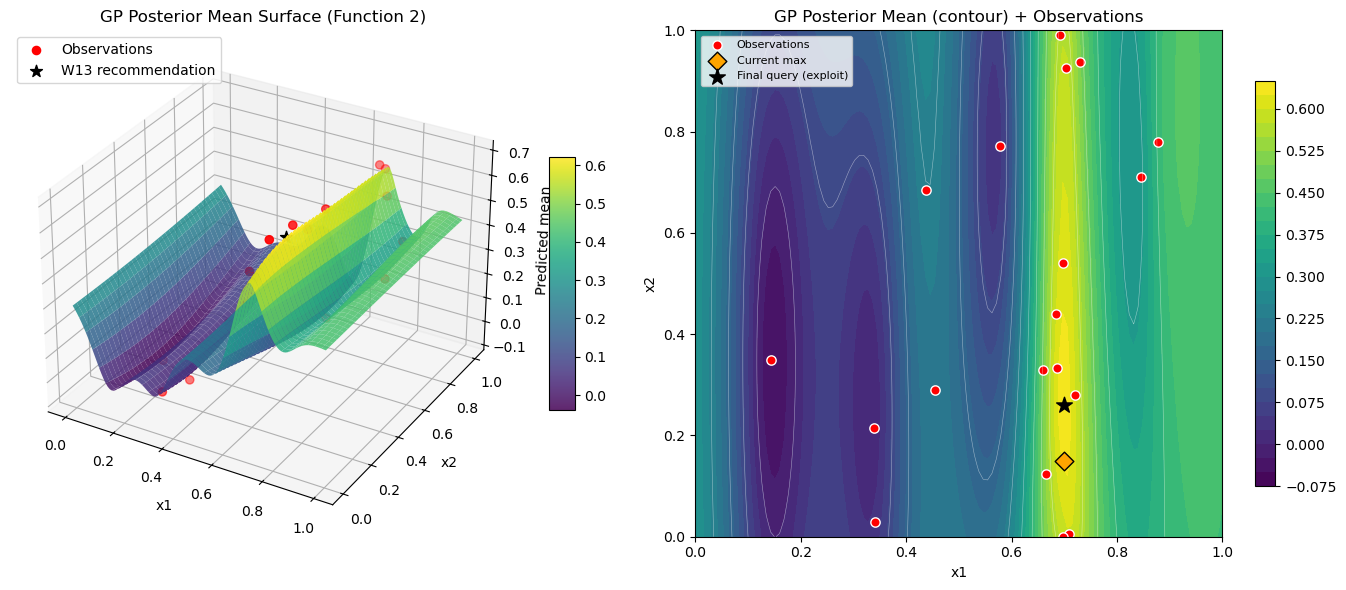

In [13]:
# GP posterior-mean surface
# 3D surface plus a 2D contour of the fitted posterior mean over $[0,1]^2$, with all observations, 
# the current record, and the W13 recommendation overlaid.

# =============================================================================
# Plot: GP posterior-mean surface over [0,1]^2 with observations + recommendation
# =============================================================================
n_grid = 120
gx = np.linspace(0, 1, n_grid)
gy = np.linspace(0, 1, n_grid)
GX, GY = np.meshgrid(gx, gy)
grid = np.column_stack([GX.ravel(), GY.ravel()])
mu_grid, std_grid = gp_F2.predict(grid, return_std=True)
MU = mu_grid.reshape(GX.shape)
STD = std_grid.reshape(GX.shape)

fig = plt.figure(figsize=(14, 6))

# 3D surface of posterior mean
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
surf = ax1.plot_surface(GX, GY, MU, cmap="viridis", alpha=0.85, linewidth=0, antialiased=True)
ax1.scatter(X_F2[:, 0], X_F2[:, 1], y_F2, color="red", s=35, depthshade=True, label="Observations")
ax1.scatter([query_F2[0]], [query_F2[1]], [best_mu_F2], color="black", s=80, marker="*",
            label="W13 recommendation")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_zlabel("Predicted mean")
ax1.set_title("GP Posterior Mean Surface (Function 2)")
ax1.legend(loc="upper left")
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# 2D contour with points overlaid
ax2 = fig.add_subplot(1, 2, 2)
cf = ax2.contourf(GX, GY, MU, levels=30, cmap="viridis")
ax2.contour(GX, GY, MU, levels=10, colors="white", linewidths=0.4, alpha=0.5)
ax2.scatter(X_F2[:, 0], X_F2[:, 1], c="red", edgecolor="white", s=45, label="Observations")
ax2.scatter(all_inputs_F2[max_idx_F2, 0], all_inputs_F2[max_idx_F2, 1],
            c="orange", edgecolor="black", s=90, marker="D", label="Current max")
ax2.scatter(query_F2[0], query_F2[1], c="black", s=140, marker="*", label="Final query (exploit)")
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
ax2.set_title("GP Posterior Mean (contour) + Observations")
ax2.legend(loc="upper left", fontsize=8)
fig.colorbar(cf, ax=ax2, shrink=0.8)

plt.tight_layout()
plt.show()

# Function 3, A drug discovery project, 3D array, 15 original samples - Week 13

In [14]:
# =============================================================================
# Function 3, A drug discovery project, 3D array, 15 original samples
# =============================================================================
# Previous weeks
# W3: Explicitly mixes exploration (random candidates), local exploitation (perturbations near the best point), 
#     and hypothesis-driven exploitation (directed candidates).
# W4: GP EI (ξ = 0.001, exploitation-biased) blended 50/50 with quadratic polynomial surrogate
# W5: Random Forest trained on degree-2 polynomial features; argmax over 10,000 global candidates
# W6: ExtraTrees (200 trees); Degree-2 polynomial interactions; Argmax over RF predictions
# W7: ExtraTrees + polynomial features; max_features: None vs. sqrt
# W8: ExtraTrees (WLS-weighted, polynomial features) + LCB (κ = 0.5) with exclusion filter
# W9: ExtraTrees surrogate with polynomial feature expansion; Ensemble disagreement and nonlinear feature interactions
# W10: ExtraTrees on log(-Y) + polynomial features, with LCB acquisition (κ = 0.3).
# W11: ExtraTrees (200 trees) on degree-2 polynomial features, log(-Y) target; LCB (κ=0.3), min-distance filter
#      W11: max_features='sqrt', min_samples_leaf=2, min_distance=0.001. 
#      W11: LOO-CV comparison across none/sqrt/log transforms picked log as best fit.
# W12: Bootstrap ensemble (n=500) of local Ridge models, fit only inside 0.15-radius basin around best
#      UCB on local perturbations around best point

print("\n" + "=" * 60)
print("Function 3 - Week 13 - Final")
print("=" * 60)

f3_inputs = np.load('initial_data/function_3/initial_inputs.npy')
f3_outputs = np.load('initial_data/function_3/initial_outputs.npy')

prev_queries_F3 = np.array([
    [0.540087, 0.652622, 0.079307],              # W2
    [0.378956, 0.302768, 0.459346],              # W3
    [0.375610, 0.057061, 0.589980],              # W4
    [0.378956, 0.302768, 0.459346],              # W5
    [0.378956, 0.302768, 0.459346],              # W6 (it was same as W5) (max, current best)
    [0.494932, 0.994690, 0.457121],              # W7
    [0.398479, 0.316913, 0.467387],              # W8
    [0.321464, 0.375442, 0.524156],              # W9
    [0.371804, 0.301322, 0.451223],              # W10
    [0.395514, 0.311838, 0.461924],              # W11 (second best)
    [0.403651, 0.271200, 0.429849],              # W12 
])
prev_outputs_F3 = np.array([
    -0.050615,               # W2 (fail)
    -0.019508,               # W3 (above initial max)
    -0.119425,               # W4 (fail)
    -0.021357,               # W5 (above initial max)
    -0.015072,               # W6 (above initial max, max, best overall)
    -0.069598,               # W7 (fail)
    -0.023447,               # W8 (above initial max)
    -0.029269,               # W9 (above initial max)
    -0.018516,               # W10 (above initial max)
    -0.018112,               # W11 (above initial max, second best)
    -0.038164,               # W12 (fail)
])

all_inputs_F3  = np.vstack([f3_inputs, prev_queries_F3])
all_outputs_F3 = np.hstack([f3_outputs, prev_outputs_F3])

max_idx_F3 = np.argmax(all_outputs_F3)
max_F3 = all_outputs_F3[max_idx_F3]
print(f"Total points: {len(all_outputs_F3)}")
print(f"Current max: {max_F3:.6e} at {all_inputs_F3[max_idx_F3]}")
print("Aim: maximise the output, apply pure exploitation.")


Function 3 - Week 13 - Final
Total points: 26
Current max: -1.507200e-02 at [0.378956 0.302768 0.459346]
Aim: maximise the output, apply pure exploitation.


In [15]:
# =============================================================================
# Week 13: Pure exploitation - final query for Function 3
# =============================================================================
# Rationale: W3/W5/W6/W8-W11 have all converged into one tight basin around [0.379, 0.303, 0.459]
#     with noisy repeat evaluations (-0.0151/-0.0195/-0.0214 at the *same* input). 
# Everything outside that basin is much worse. 
# So this week does NOT explore -> it fits a local surrogate 
#    on the converged basin only and exploits it directly (posterior mean, no UCB/kappa term).

# ---- restrict to the converged basin around the incumbent best ----
BASIN_RADIUS_F3 = 0.15
dists_F3 = np.linalg.norm(all_inputs_F3 - all_inputs_F3[max_idx_F3], axis=1)
basin_mask_F3 = dists_F3 < BASIN_RADIUS_F3
Xb_F3, Yb_F3 = all_inputs_F3[basin_mask_F3], all_outputs_F3[basin_mask_F3]

poly_F3 = PolynomialFeatures(degree=2, include_bias=True)
Xb_poly_F3 = poly_F3.fit_transform(Xb_F3)

# ---- bootstrap ensemble of ridge-regularised local quadratic models ----
# (same surrogate family as W12; the only change is the acquisition: 
#     pure exploitation = argmax of the mean prediction, no exploration bonus)

rng_F3 = np.random.default_rng(13)
N_BOOT_F3, ALPHA_F3 = 500, 5.0

# candidates are restricted to a tight box around the *already explored*
# basin so the surrogate is never trusted to extrapolate outside it

margin_F3 = 0.02
lo_F3 = np.clip(Xb_F3.min(axis=0) - margin_F3, 0, 1)
hi_F3 = np.clip(Xb_F3.max(axis=0) + margin_F3, 0, 1)
n_cand_F3 = 50_000
candidates_F3 = rng_F3.uniform(lo_F3, hi_F3, size=(n_cand_F3, 3))
candidates_poly_F3 = poly_F3.transform(candidates_F3)

preds_F3 = np.zeros((N_BOOT_F3, n_cand_F3))
for b in range(N_BOOT_F3):
    idx = rng_F3.integers(0, len(Yb_F3), size=len(Yb_F3))
    ridge = Ridge(alpha=ALPHA_F3)
    ridge.fit(Xb_poly_F3[idx], Yb_F3[idx])
    preds_F3[b] = ridge.predict(candidates_poly_F3)

mean_pred_F3 = preds_F3.mean(axis=0)
std_pred_F3 = preds_F3.std(axis=0)

best_cand_idx_F3 = np.argmax(mean_pred_F3)          # pure exploitation: argmax(mean)
query_F3 = candidates_F3[best_cand_idx_F3]

print("\n" + "=" * 60)
print("W13 (final) predicted query - pure exploitation")
print("=" * 60)

print(f"Basin size used for surrogate : {len(Yb_F3)} points (radius {BASIN_RADIUS_F3})")
print(f"Incumbent best                : {all_inputs_F3[max_idx_F3]} -> y = {max_F3:.6e}")
print()
print(f"Next query F3                 : {format_query(query_F3)}")
print(f"Surrogate mean prediction     : {mean_pred_F3[best_cand_idx_F3]:.6e}  "
      f"(+/- {std_pred_F3[best_cand_idx_F3]:.2e})")
print(f"Distance from incumbent best  : {np.linalg.norm(query_F3 - all_inputs_F3[max_idx_F3]):.4f}")


W13 (final) predicted query - pure exploitation
Basin size used for surrogate : 8 points (radius 0.15)
Incumbent best                : [0.378956 0.302768 0.459346] -> y = -1.507200e-02

Next query F3                 : [0.422378-0.269491-0.411072]
Surrogate mean prediction     : -2.281924e-02  (+/- 2.42e-03)
Distance from incumbent best  : 0.0730


C:\Users\mayzu\AppData\Local\Temp\ipykernel_12552\4117592346.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


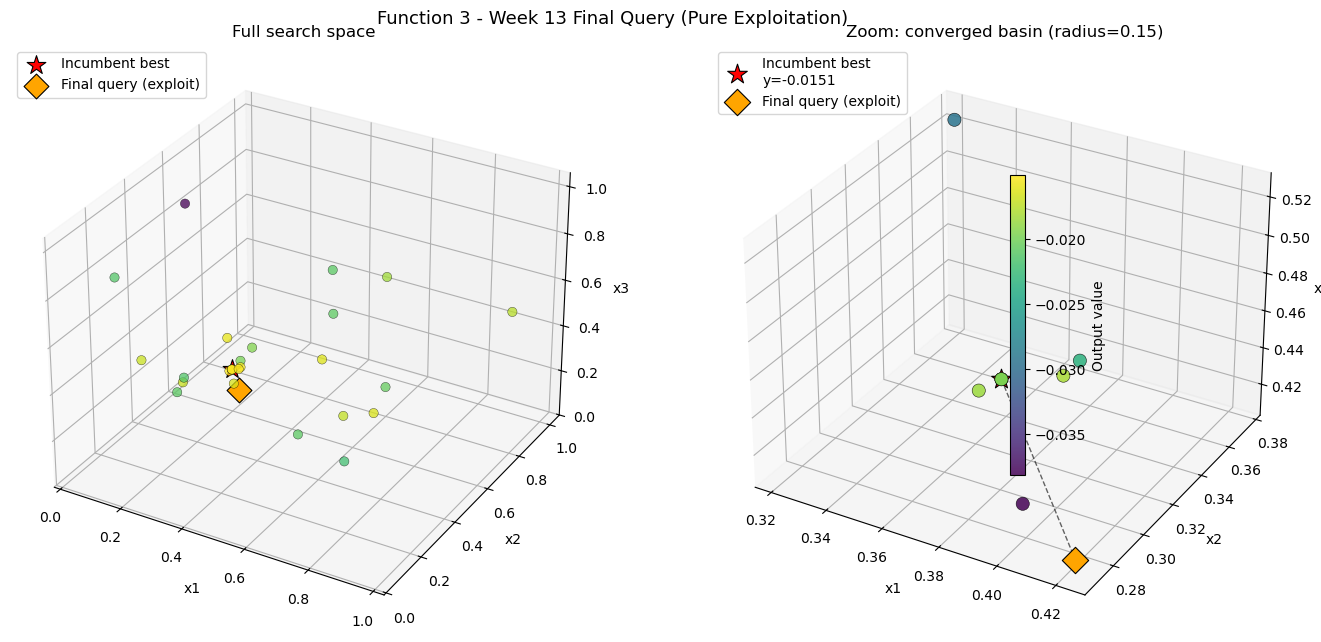

In [16]:
# =============================================================================
# Week 13: Plot the final query
# =============================================================================

best_x_F3, best_y_F3 = all_inputs_F3[max_idx_F3], max_F3

fig = plt.figure(figsize=(14, 6.5))

# Panel 1: full search space
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(all_inputs_F3[:, 0], all_inputs_F3[:, 1], all_inputs_F3[:, 2],
            c=all_outputs_F3, cmap='viridis', s=45, alpha=0.75,
            edgecolors='k', linewidths=0.3)
ax1.scatter(*best_x_F3, c='red', s=200, marker='*', edgecolors='k',
            linewidths=0.8, label='Incumbent best')
ax1.scatter(*query_F3, c='orange', s=160, marker='D', edgecolors='k',
            linewidths=0.8, label='Final query (exploit)')
ax1.set_xlabel('x1'); ax1.set_ylabel('x2'); ax1.set_zlabel('x3')
ax1.set_title('Full search space')
ax1.legend(loc='upper left')

# Panel 2: zoom into the converged basin
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(Xb_F3[:, 0], Xb_F3[:, 1], Xb_F3[:, 2], c=Yb_F3, cmap='viridis', s=90,
                   alpha=0.85, edgecolors='k', linewidths=0.4)
ax2.scatter(*best_x_F3, c='red', s=220, marker='*', edgecolors='k',
            linewidths=0.8, label=f'Incumbent best\ny={best_y_F3:.4f}')
ax2.scatter(*query_F3, c='orange', s=180, marker='D', edgecolors='k',
            linewidths=0.8, label='Final query (exploit)')
ax2.plot([best_x_F3[0], query_F3[0]], [best_x_F3[1], query_F3[1]],
         [best_x_F3[2], query_F3[2]], 'k--', alpha=0.6, linewidth=1)
ax2.set_xlabel('x1'); ax2.set_ylabel('x2'); ax2.set_zlabel('x3')
ax2.set_title(f'Zoom: converged basin (radius={BASIN_RADIUS_F3})')
ax2.legend(loc='upper left')

cbar = fig.colorbar(sc2, ax=[ax1, ax2], shrink=0.6, pad=0.02)
cbar.set_label('Output value')

fig.suptitle('Function 3 - Week 13 Final Query (Pure Exploitation)', fontsize=13)
plt.tight_layout()
plt.show()

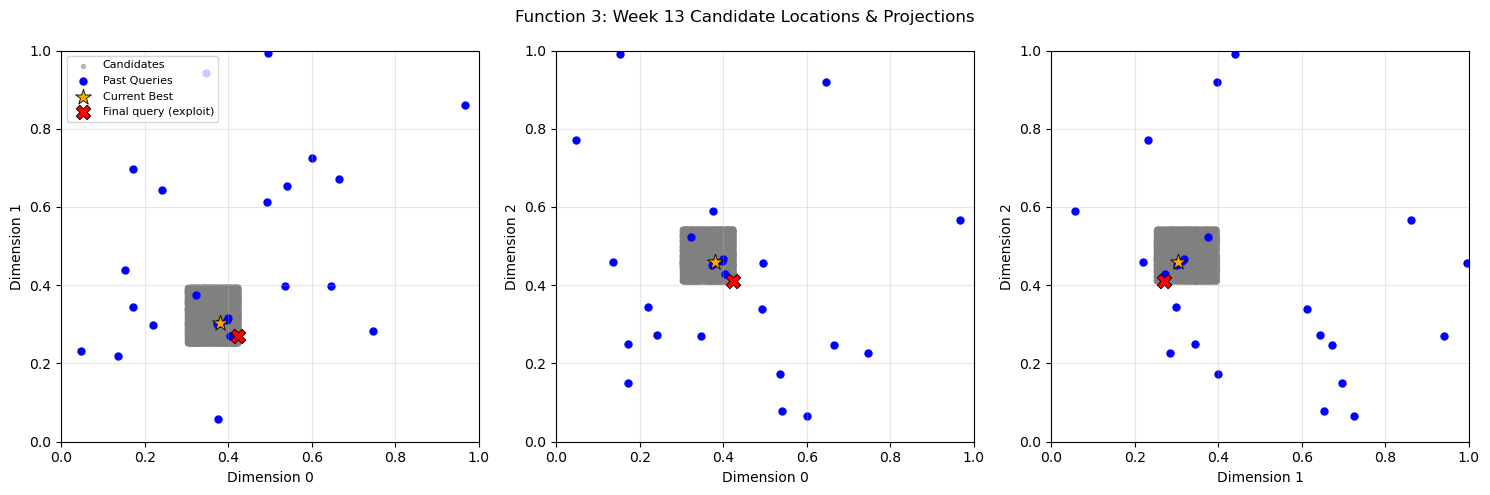

In [17]:
# ================================================
# W13-style 3-panel candidate/projection plot 
# ================================================

dim_pairs = [(0, 1), (0, 2), (1, 2)]
dim_labels = ['Dimension 0', 'Dimension 1', 'Dimension 2']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (d1, d2) in zip(axes, dim_pairs):
    ax.scatter(candidates_F3[:, d1], candidates_F3[:, d2],
               s=8, c='gray', alpha=0.5, label='Candidates')
    ax.scatter(all_inputs_F3[:, d1], all_inputs_F3[:, d2],
               s=25, c='blue', label='Past Queries')
    ax.scatter(best_x_F3[d1], best_x_F3[d2],
               s=140, c='orange', marker='*', edgecolors='k',
               linewidths=0.6, label='Current Best', zorder=5)
    ax.scatter(query_F3[d1], query_F3[d2],
               s=110, c='red', marker='X', edgecolors='k',
               linewidths=0.6, label='Final query (exploit)', zorder=6)
    ax.set_xlabel(dim_labels[d1])
    ax.set_ylabel(dim_labels[d2])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

axes[0].legend(loc='upper left', fontsize=8)
fig.suptitle('Function 3: Week 13 Candidate Locations & Projections')
plt.tight_layout()
plt.show()

# Function 4, Warehouse business, 4D array, 30 original samples - Week 13

In [18]:
# =============================================================================
# Function 4, Warehouse business, 4D array, 30 original samples
# =============================================================================
# Previous weeks
# W3: Exploration-oriented due to relatively high (UCB, κ = 2.0) over 10k uniformly random candidates.
# W4: GP (Matérn) + Thompson sampling
# W5: RF surrogate; uncertainty estimated from tree-to-tree disagreement (rf_predict_with_std); 
#     acquisition = EI (ξ = 0.01) over Latin Hypercube candidates
# W6: SVM classifier (gate) + ARD GP (refine); Threshold-based binary labelling; EI
# W7: SVM gate + GP (EI); SVM probability threshold; Increased GP α to smooth noisy responses and added global; added global LHS
# W8: GP (Matérn, selected over RF using LOO R²) + UCB (κ = 0.5)
#     W8: Mixed strategy: local candidate pools around three promising regions, with relatively low κ favouring exploitation
#     W8: RF LOO R² (0.70) substantially underperformed GP LOO R² (0.91)
# W9: GP with extensive diagnostic visualisations; Human interpretation of response surfaces guides subsequent exploration
# W10: GP (Matérn, fixed length-scale) with EI computed, 
#      but query actually selected via argmax(mu)— for safe and Pure Exploitation, rather than Expected Improvement.
# W11: GP, Matérn ν=2.5	EI (ξ=0.01), switched from UCB. 
#     Candidate pool built from local perturbations (σ=0.08) around W7/W8 queries + global random, rather than a single scheme.
# W12: GP, Constant×Matérn ν=2.5 (learned length scale) + WhiteKernel; chosen via higher log-marginal-likelihood
#     EI vs. best-so-far over mixed pool (σ=0.08/0.02 local + global); final pick restricted to tight (σ=0.02) band
 
print("\n" + "=" * 60)
print("Function 4 - Week 13 - Final")
print("=" * 60)

f4_inputs  = np.load('initial_data/function_4/initial_inputs.npy')
f4_outputs = np.load('initial_data/function_4/initial_outputs.npy')

prev_queries_F4 = np.array([
    [0.149845, 0.155724, 0.461280, 0.344491],              # W2
    [0.330258, 0.414348, 0.433728, 0.411341],              # W3
    [0.424125, 0.404716, 0.487507, 0.367688],              # W4
    [0.424125, 0.404716, 0.487507, 0.367688],              # W5 (it was the same as Week 4)
    [0.255396, 0.450674, 0.468413, 0.490566],              # W6
    [0.371614, 0.422247, 0.370132, 0.421911],              # W7 (second best)
    [0.378911, 0.420065, 0.360647, 0.355610],              # W8 (max, best overall)
    [0.431137, 0.410316, 0.341871, 0.422095],              # W9
    [0.372317, 0.403232, 0.376261, 0.38097],               # W10
    [0.420876, 0.518558, 0.358976, 0.385896],              # W11
    [0.380314, 0.376647, 0.336052, 0.410761],              # W12
])
prev_outputs_F4 = np.array([-7.13212,          # W2 fail
                            0.20379,           # W3 (above initial max)
                            -0.99160,          # W4 (above initial max)
                            -0.99147,          # W5 (above initial max)
                            -3.142015,         # W6 (above initial max)
                            0.657358,          # W7 (above initial max, second best)
                            0.664078,          # W8 (above initial max, max, best overall)
                            0.47213,           # W9 (above initial max)
                            0.27362,           # W10 (above initial max)
                            -1.33442,          # W10 (above initial max)
                            0.19180,           # W12 (above initial max)
                           ]) 

all_inputs_F4  = np.vstack([f4_inputs, prev_queries_F4])
all_outputs_F4 = np.hstack([f4_outputs, prev_outputs_F4])

max_idx_F4 = np.argmax(all_outputs_F4)
max_F4 = all_outputs_F4[max_idx_F4]
print(f"Total points: {len(all_outputs_F4)}")
print(f"Current max: {max_F4:.6e} at {all_inputs_F4[max_idx_F4]}")
print("Aim: maximise the output, apply pure exploitation.")


Function 4 - Week 13 - Final
Total points: 41
Current max: 6.640780e-01 at [0.378911 0.420065 0.360647 0.35561 ]
Aim: maximise the output, apply pure exploitation.


In [19]:
# =============================================================================
# W13: GP surrogate + PURE EXPLOITATION (argmax mu, no EI/UCB)
# =============================================================================

# --- Model selection: compare a few length-scale-bound regimes via LOO R^2
# (same spirit as W8's RF-vs-GP LOO R^2 comparison, and W12's "chosen via higher log-marginal-likelihood")

candidate_ubs_F4 = [0.3, 0.5, 0.8, 1.0, 2.0]
best_ub_F4, best_r2_F4 = None, -np.inf

loo_F4 = LeaveOneOut()
for ub in candidate_ubs_F4:
    preds_F4 = np.zeros_like(all_outputs_F4)
    for tr, te in loo_F4.split(all_inputs_F4):
        k = (ConstantKernel(1.0, (1e-3, 1e3))
             * Matern(length_scale=np.ones(4) * 0.3,
                       length_scale_bounds=(1e-2, ub), nu=2.5)
             + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-8, 1e0)))
        gp_cv_F4 = GaussianProcessRegressor(kernel=k, normalize_y=True,
                                             n_restarts_optimizer=3, random_state=0)
        gp_cv_F4.fit(all_inputs_F4[tr], all_outputs_F4[tr])
        preds_F4[te] = gp_cv_F4.predict(all_inputs_F4[te])
    r2_F4 = r2_score(all_outputs_F4, preds_F4)
    print(f"length_scale upper bound={ub}: LOO R^2 = {r2_F4:.4f}")
    if r2_F4 > best_r2_F4:
        best_r2_F4, best_ub_F4 = r2_F4, ub

print(f"\nSelected length_scale upper bound: {best_ub_F4} (LOO R^2={best_r2_F4:.4f})")

# --- Fit final GP on all 41 points with the selected regime
kernel_F4 = (ConstantKernel(1.0, (1e-3, 1e3))
             * Matern(length_scale=np.ones(4) * 0.3,
                       length_scale_bounds=(1e-2, best_ub_F4), nu=2.5)
             + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-8, 1e0)))

gp_F4 = GaussianProcessRegressor(kernel=kernel_F4, normalize_y=True,
                                  n_restarts_optimizer=20, random_state=42)
gp_F4.fit(all_inputs_F4, all_outputs_F4)
print("Fitted kernel:", gp_F4.kernel_)
print("Log-marginal-likelihood:", gp_F4.log_marginal_likelihood_value_)

# Candidate pool: tight local perturbations around the top-2 points (W8 max and W7 second-best)
# mirrors W12's "final pick restricted to a tight band", but selection is now PURE argmax(mu), no EI/UCB term.

rng_F4 = np.random.default_rng(7)
top2_idx_F4 = np.argsort(all_outputs_F4)[-2:]
top2_points_F4 = all_inputs_F4[top2_idx_F4]

sigma_F4 = 0.02
n_per_center_F4 = 3000
candidates_F4 = np.vstack([
    np.clip(p + rng_F4.normal(0, sigma_F4, size=(n_per_center_F4, 4)), 0, 1)
    for p in top2_points_F4
])

mu_F4, std_F4 = gp_F4.predict(candidates_F4, return_std=True)
best_i_F4 = np.argmax(mu_F4)                      # <-- pure exploitation: argmax(mu)
query_F4 = candidates_F4[best_i_F4]


print("\n" + "=" * 60)
print("W13 (final) predicted query - pure exploitation")
print("=" * 60)

print(f"Next query F4   : {format_query(np.round(query_F4, 7))}")
print(f"Predicted mean:  {mu_F4[best_i_F4]:.6f}")
print(f"Predicted std:   {std_F4[best_i_F4]:.6f}")
print(f"Current best-so-far output: {max_F4:.6f}")
print(f"Distance from current best point: "
      f"{np.linalg.norm(query_F4 - all_inputs_F4[max_idx_F4]):.4f}")
print("=" * 60)

length_scale upper bound=0.3: LOO R^2 = 0.7639
length_scale upper bound=0.5: LOO R^2 = 0.8847
length_scale upper bound=0.8: LOO R^2 = 0.9520
length_scale upper bound=1.0: LOO R^2 = 0.9697
length_scale upper bound=2.0: LOO R^2 = 0.9859

Selected length_scale upper bound: 2.0 (LOO R^2=0.9859)
Fitted kernel: 3.45**2 * Matern(length_scale=[1.76, 1.73, 1.85, 1.69], nu=2.5) + WhiteKernel(noise_level=0.00174)
Log-marginal-likelihood: -0.6280324277266587

W13 (final) predicted query - pure exploitation
Next query F4   : [0.40142 -0.38321 -0.356729-0.411328]
Predicted mean:  0.499878
Predicted std:   0.442706
Current best-so-far output: 0.664078
Distance from current best point: 0.0706


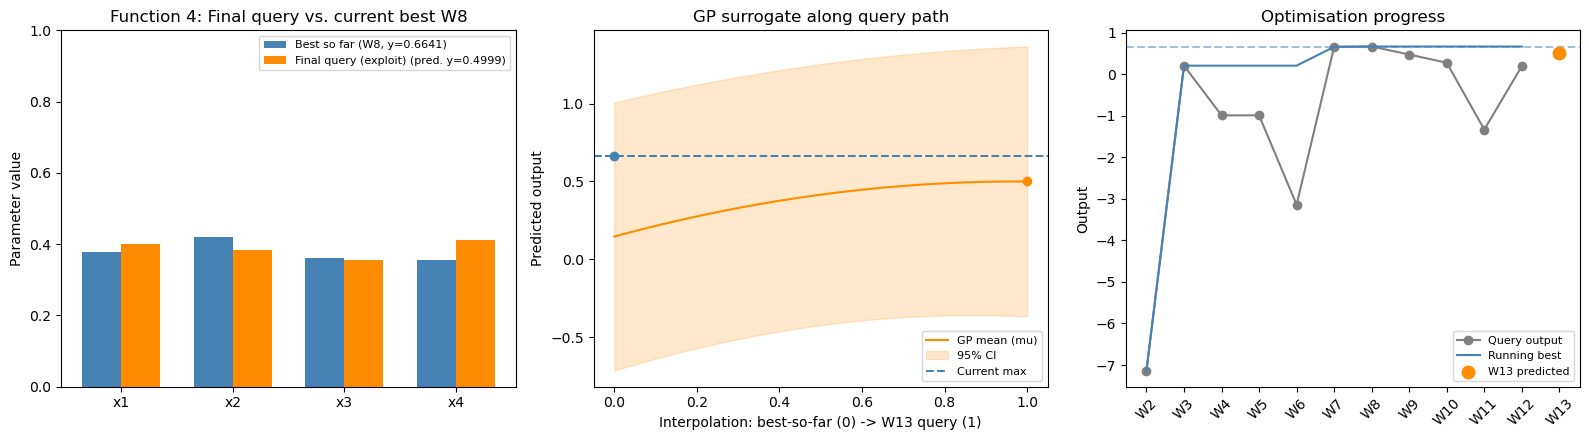

In [20]:
# =============================================================================
# Plot the Week 13 query: (1) parameter comparison vs current best,
# (2) predicted mu along the line between current best and the new query,
# (3) optimisation progress across weeks
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# --- (1) Parameter-by-parameter comparison bar chart
dims = ['x1', 'x2', 'x3', 'x4']
x_pos = np.arange(len(dims))
width = 0.35
axes[0].bar(x_pos - width/2, all_inputs_F4[max_idx_F4], width,
            label=f'Best so far (W8, y={max_F4:.4f})', color='steelblue')
axes[0].bar(x_pos + width/2, query_F4, width,
            label=f'Final query (exploit) (pred. y={mu_F4[best_i_F4]:.4f})', color='darkorange')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(dims)
axes[0].set_ylabel('Parameter value')
axes[0].set_title('Function 4: Final query vs. current best W8')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1)

# --- (2) GP mean (and 95% band) interpolated between best-so-far and new query
alphas = np.linspace(0, 1, 100)
line_pts = (1 - alphas[:, None]) * all_inputs_F4[max_idx_F4] + alphas[:, None] * query_F4
mu_line, std_line = gp_F4.predict(line_pts, return_std=True)
axes[1].plot(alphas, mu_line, color='darkorange', label='GP mean (mu)')
axes[1].fill_between(alphas, mu_line - 1.96*std_line, mu_line + 1.96*std_line,
                      color='darkorange', alpha=0.2, label='95% CI')
axes[1].axhline(max_F4, color='steelblue', linestyle='--', label='Current max')
axes[1].scatter([0], [max_F4], color='steelblue', zorder=5)
axes[1].scatter([1], [mu_F4[best_i_F4]], color='darkorange', zorder=5)
axes[1].set_xlabel('Interpolation: best-so-far (0) -> W13 query (1)')
axes[1].set_ylabel('Predicted output')
axes[1].set_title('GP surrogate along query path')
axes[1].legend(fontsize=8)

# --- (3) Progress across weeks (best-so-far output vs week)
week_labels = ['W2','W3','W4','W5','W6','W7','W8','W9','W10','W11','W12']
running_best = np.maximum.accumulate(prev_outputs_F4)
axes[2].plot(week_labels, prev_outputs_F4, 'o-', color='gray', label='Query output')
axes[2].plot(week_labels, running_best, color='steelblue', label='Running best')
axes[2].scatter(['W13'], [mu_F4[best_i_F4]], color='darkorange', s=80, zorder=5,
                 label='W13 predicted')
axes[2].axhline(max_F4, color='steelblue', linestyle='--', alpha=0.5)
axes[2].set_ylabel('Output')
axes[2].set_title('Optimisation progress')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

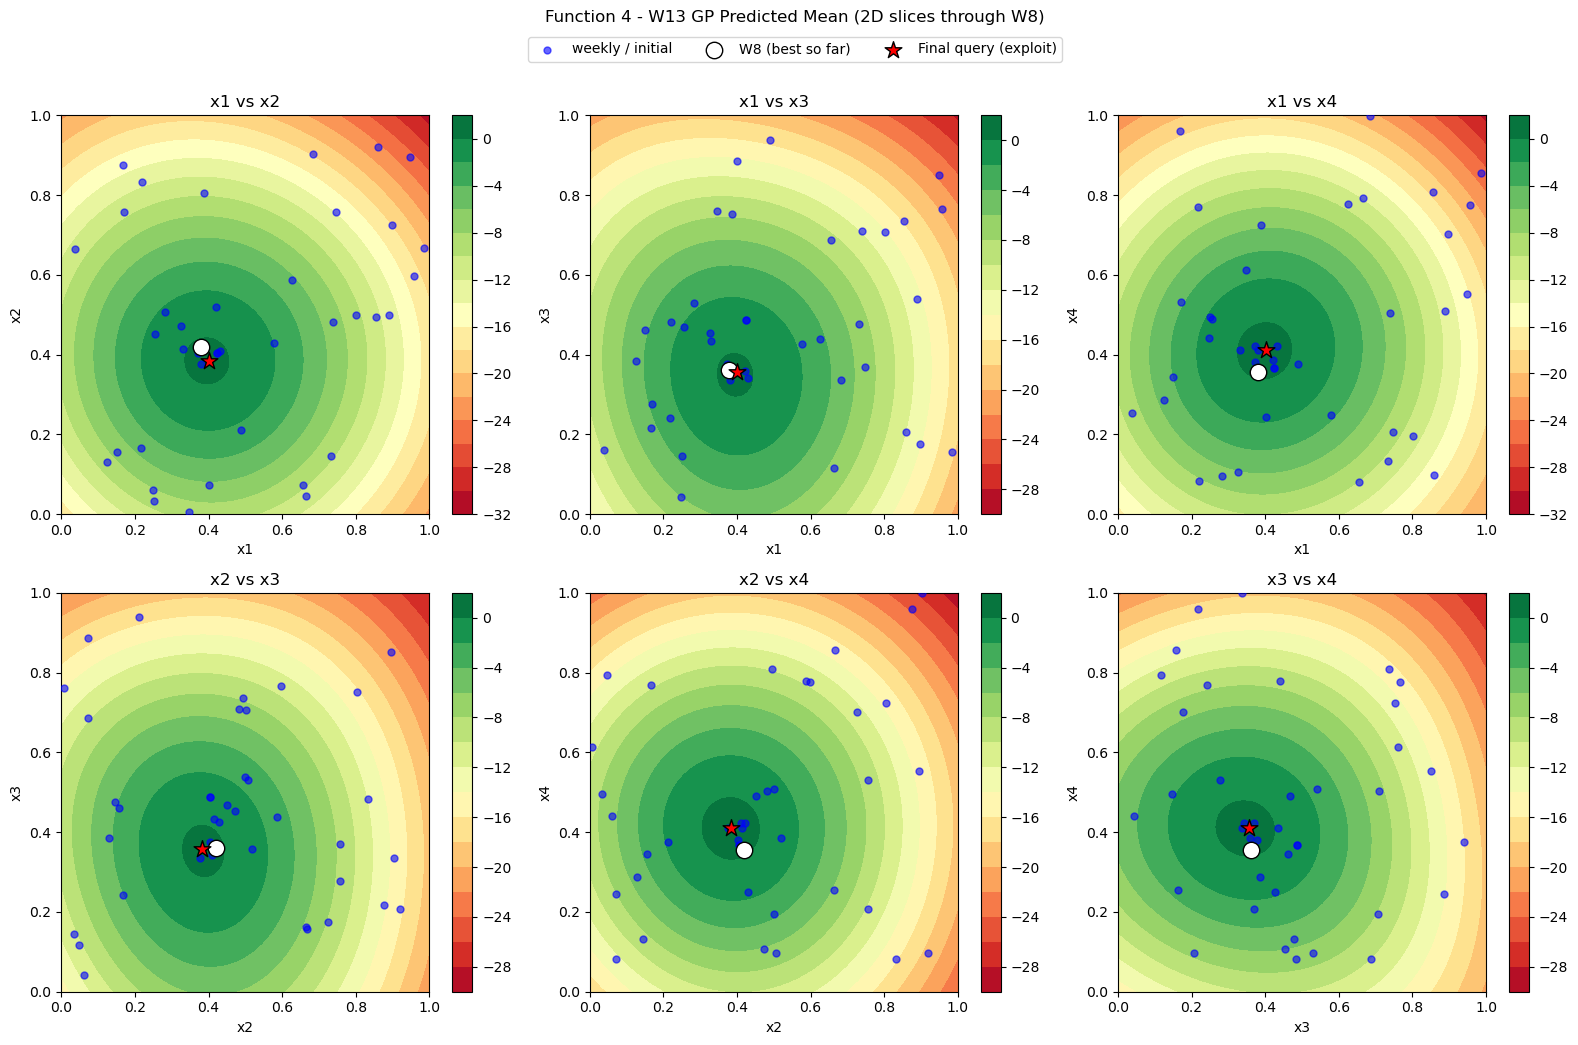

In [21]:
# =============================================================================
# W13: 2D contour slices of the GP predicted mean, through the W8 point
# =============================================================================

dims = ['x1', 'x2', 'x3', 'x4']
slice_point = all_inputs_F4[max_idx_F4]   # W8 — the point we slice through
n_grid = 100
grid_1d = np.linspace(0, 1, n_grid)

pairs = list(itertools.combinations(range(4), 2))  # (0,1),(0,2),(0,3),(1,2),(1,3),(2,3)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for ax, (i, j) in zip(axes, pairs):
    # Build a grid over dims i and j; all other dims fixed at the W8 slice point
    Xi, Xj = np.meshgrid(grid_1d, grid_1d)
    grid_points = np.tile(slice_point, (n_grid * n_grid, 1))
    grid_points[:, i] = Xi.ravel()
    grid_points[:, j] = Xj.ravel()

    mu_grid = gp_F4.predict(grid_points).reshape(n_grid, n_grid)

    cs = ax.contourf(Xi, Xj, mu_grid, levels=15, cmap='RdYlGn')
    fig.colorbar(cs, ax=ax)

    # Overlay: all weekly queries (projected onto this pair of dims)
    ax.scatter(all_inputs_F4[:, i], all_inputs_F4[:, j],
               color='blue', s=25, alpha=0.6, label='weekly / initial', zorder=3)

    # Overlay: W8 (current best) and the new W13 query
    ax.scatter(slice_point[i], slice_point[j],
               color='white', edgecolor='black', s=140, marker='o',
               label='W8 (best so far)', zorder=5)
    ax.scatter(query_F4[i], query_F4[j],
               color='red', edgecolor='black', s=160, marker='*',
               label='Final query (exploit)', zorder=5)

    ax.set_xlabel(dims[i])
    ax.set_ylabel(dims[j])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f'{dims[i]} vs {dims[j]}')

# Single shared legend (avoid repeating it on every subplot)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.02))
fig.suptitle('Function 4 - W13 GP Predicted Mean (2D slices through W8)', y=1.04)

plt.tight_layout()
plt.show()

# Function 5, Chemical process in a factory, 4D, 20 original samples - Week 13

In [22]:
# =============================================================================
# Function 5, A chemical process in a factory, 4D array, 20 original samples
# =============================================================================
# Previous weeks
# W3: Strong exploitation
#     SVR ranks a locally generated candidate pool (local perturbations and directional moves around the incumbent). 
# W4: Linear regression (search direction) → SVR pre-filter → GP EI (ξ = 0.005)
# W5: Two-stage approach: SVR pre-filters candidates (top 3,000 retained), 
#     then GP (log-transformed outputs, Matérn kernel) evaluates them using EI (ξ = 0.005)
# W6: SVR + GP (log space); Log transform of output; EI
# W7: SVR filter + GP (EI); SVR candidate pool = 3000; EI ξ = 0.005; improving search coverage
# W8: SVR pre-filter (top 3000 candidates) → GP (log-transformed outputs) + EI (ξ = 0.005)
# W9: GP with constrained local and boundary search; Boundary pinning and structured perturbations alter search dynamics
# W10: SVR pre-filter → GP (log1p outputs), EI (ξ=0.005)
#      Out-of-bounds historical points explicitly excluded from training
# W11: 	SVR pre-filter → GP (log1p outputs), EI (ξ=0.005)	
#       SVR: C=100, gamma='scale', epsilon=0.01; GP: length_scale=0.2, n_restarts_optimizer=25
# W12: SVR (RBF) + GP (Matérn ν=2.5, log1p target), both trained on in-bounds data only, cross-checked via LOO
#      Pure exploitation — argmax(GP mean); SVR as agreement check only
#     SVR: C=100, γ=scale, ε=0.01; GP length_scale=0.3
 
# -------------------------------------------------------------------
# 1. Load historical data | Function 5 - Week 13 - Final
# -------------------------------------------------------------------

f5_inputs  = np.load('initial_data/function_5/initial_inputs.npy')
f5_outputs = np.load('initial_data/function_5/initial_outputs.npy')

prev_queries_F5 = np.array([
    [0.417098, 0.756030, 0.129487, 1.149173],               # W2 
    [0.386633, 0.821843, 0.127990, 0.999900],               # W3
    [0.269378, 0.810637, 0.999999, 0.999999],               # W4 
    [0.366671, 0.879874, 0.999999, 0.996800],               # W5 
    [0.495228, 0.809693, 0.999999, 0.999990],               # W6 
    [0.382122, 0.995456, 0.999999, 0.999999],               # W7 
    [0.566703, 0.999727, 0.999999, 0.999999],               # W8 
    [0.626657, 0.999999, 0.999999, 0.999999],               # W9 
    [0.656411, 1.185597, 1.026548, 1.160768],               # W10 (beyond 0 to 1 search space)
    [0.847572, 1.000000, 1.000000, 1.000000],               # W11 (second best)
    [0.976764, 1.000000, 1.000000, 1.000000],               # W12 (max, best overall)
])
prev_outputs_F5 = np.array([1829.809875,                    # W2 (above initial max, beyond 0/1 search space)
                            710.602251,                     # W3 (fail)
                            2699.104490,                    # W4 (above initial max)
                            3179.389393,                    # W5 (above initial max)
                            2855.140103,                    # W6 (above initial max)
                            4461.243621,                    # W7 (above initial max)
                            4826.282687,                    # W8 (above initial max) 
                            5022.767511,                    # W9 (above initial max)
                            14653.360405,                   # W10 (beyond 0 to 1 search space)
                            6469.995029,                    # W11 (above initial max, second best)
                            8232.981067,                    # W12 (above initial max, max, best overall)
                           ])

all_inputs_F5  = np.vstack([f5_inputs, prev_queries_F5])
all_outputs_F5 = np.hstack([f5_outputs, prev_outputs_F5])

In [23]:
# -------------------------------------------------------------------
# 2. Strict [0,1]^4 bounds filter - exclude OOB points entirely
# -------------------------------------------------------------------
oob_mask_F5   = (all_inputs_F5 < 0).any(axis=1) | (all_inputs_F5 > 1).any(axis=1)
valid_mask_F5 = ~oob_mask_F5

Xv_F5 = all_inputs_F5[valid_mask_F5]
Yv_F5 = all_outputs_F5[valid_mask_F5]

best_idx_F5 = np.argmax(Yv_F5)
CURRENT_BEST_VALID_F5 = Yv_F5[best_idx_F5]
best_point_F5 = Xv_F5[best_idx_F5]

print("=" * 60)
print("Function 5 - Week 13 - Final")
print("=" * 60)
print(f"Valid in-bounds points used for modelling: {len(Yv_F5)}")
print(f"Current best VALID output: {CURRENT_BEST_VALID_F5:.4f}")
print(f"At point: {np.round(best_point_F5, 6)}")

Function 5 - Week 13 - Final
Valid in-bounds points used for modelling: 29
Current best VALID output: 8232.9811
At point: [0.976764 1.       1.       1.      ]


**Methodology (continuing W9-W12):**

1. Fit two models on `log1p(output)` using in-bounds data only: **SVR** (RBF, `C=100`, `γ='scale'`, `ε=0.01`) as an agreement check, and **GP** (Matérn `ν=2.5`, `length_scale=0.3` init, + white noise, `normalize_y=True`) as the decision-maker.
2. Leave-one-out cross-validation on the GP as a sanity check.
3. Build a local candidate pool (~21,000 points): multi-scale Gaussian perturbations around the incumbent `[0.976764, 1, 1, 1]`, single-axis directional sweeps, and boundary-pinned candidates pushing dimension 0 → `1`.
4. Pure exploitation: pick `argmax(GP posterior mean)` over the candidate pool; SVR prediction reported alongside purely as an agreement check.

In [24]:
# Continues the W9-W12 methodology:
#    SVR (RBF) pre-filter / agreement-check + GP (Matern nu=2.5, log1p-transformed target),
#    both trained on IN-BOUNDS data only.
#    Pure exploitation: argmax(GP posterior mean).
#    SVR is used only as a cross-check (does it broadly agree with GP?),  not to filter candidates this week, 
#    since we are now purely exploiting a tightly known local region around the incumbent.
    
# -------------------------------------------------------------------
# 3. Fit models on log1p(output), in-bounds data only
# -------------------------------------------------------------------
Yv_log_F5 = np.log1p(Yv_F5)

svr_F5 = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.01)
svr_F5.fit(Xv_F5, Yv_log_F5)

kernel_F5 = ConstantKernel(1.0, (1e-2, 1e3)) * Matern(length_scale=0.3, length_scale_bounds=(1e-2, 2.0), nu=2.5) \
            + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e-1))
gp_F5 = GaussianProcessRegressor(kernel=kernel_F5, normalize_y=True,
                                  n_restarts_optimizer=25, random_state=13)
gp_F5.fit(Xv_F5, Yv_log_F5)

,kernel,1**2 * Matern...e_level=0.001)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,25
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,13
,kernel__k1,"1**2 * Matern...e=0.3, nu=2.5)"
,kernel__k2,WhiteKernel(noise_level=0.001)
,kernel__k1__k1,1**2


In [25]:
# -------------------------------------------------------------------
# 4. Leave-one-out cross-check (sanity check on GP, as in W12)
# -------------------------------------------------------------------
loo_F5 = LeaveOneOut()
loo_err_F5 = []
for train_idx, test_idx in loo_F5.split(Xv_F5):
    gp_cv_F5 = GaussianProcessRegressor(kernel=kernel_F5, normalize_y=True,
                                         n_restarts_optimizer=5, random_state=13)
    gp_cv_F5.fit(Xv_F5[train_idx], Yv_log_F5[train_idx])
    pred = gp_cv_F5.predict(Xv_F5[test_idx])
    loo_err_F5.append(np.expm1(pred[0]) - Yv_F5[test_idx[0]])
loo_err_F5 = np.array(loo_err_F5)
print(f"\nLOO cross-check: mean abs error = {np.mean(np.abs(loo_err_F5)):.2f}, "
      f"RMSE = {np.sqrt(np.mean(loo_err_F5**2)):.2f}")


LOO cross-check: mean abs error = 131.35, RMSE = 280.76


In [26]:
# -------------------------------------------------------------------
# 5. Candidate pool - pure exploitation around the incumbent
#    (local perturbations + directional pushes + boundary pinning)
# -------------------------------------------------------------------
n_local_F5 = 20000
scales_F5 = [0.15, 0.08, 0.04, 0.02, 0.01]   # multi-scale local search
cand_list_F5 = [best_point_F5]

for s in scales_F5:
    perturb = rng.normal(0, s, size=(n_local_F5 // len(scales_F5), 4))
    cands = np.clip(best_point_F5 + perturb, 0, 1)
    cand_list_F5.append(cands)

# directional pushes along each axis toward/away from boundary
for dim in range(4):
    steps = np.linspace(-0.3, 0.3, 200)
    dir_cands = np.tile(best_point_F5, (len(steps), 1))
    dir_cands[:, dim] = np.clip(best_point_F5[dim] + steps, 0, 1)
    cand_list_F5.append(dir_cands)

# boundary-pinned corners near incumbent (push dim0 toward 1 as well)
corner_steps = np.linspace(0.9, 1.0, 100)
corner_cands = np.tile([0, 1, 1, 1], (len(corner_steps), 1)).astype(float)
corner_cands[:, 0] = corner_steps
cand_list_F5.append(corner_cands)

candidates_F5 = np.vstack(cand_list_F5)
candidates_F5 = np.clip(candidates_F5, 0, 1)

In [27]:
# -------------------------------------------------------------------
# 6. Pure exploitation: argmax(GP posterior mean), SVR as agreement check
# -------------------------------------------------------------------
gp_mean_log_F5, gp_std_log_F5 = gp_F5.predict(candidates_F5, return_std=True)
gp_mean_F5 = np.expm1(gp_mean_log_F5)

svr_pred_log_F5 = svr_F5.predict(candidates_F5)
svr_pred_F5 = np.expm1(svr_pred_log_F5)

best_cand_idx_F5 = np.argmax(gp_mean_F5)
query_F5 = candidates_F5[best_cand_idx_F5]
predicted_output_gp_F5  = gp_mean_F5[best_cand_idx_F5]
predicted_output_svr_F5 = svr_pred_F5[best_cand_idx_F5]

print("\n" + "=" * 60)
print("W13 (final) predicted query - pure exploitation")
print("=" * 60)
print(f"Candidates evaluated: {len(candidates_F5)}")
print(f"Next query F5   : {format_query(np.round(query_F5, 7))}")
print(f"GP  predicted output    : {predicted_output_gp_F5:.4f}")
print(f"SVR predicted output    : {predicted_output_svr_F5:.4f}  (agreement check)")
print(f"GP predictive std (log) : {gp_std_log_F5[best_cand_idx_F5]:.4f}")
print(f"Improvement over current best ({CURRENT_BEST_VALID_F5:.4f}): "
      f"{predicted_output_gp_F5 - CURRENT_BEST_VALID_F5:+.4f}")

if predicted_output_gp_F5 > CURRENT_BEST_VALID_F5:
    print("\n=> Predicted query goes BEYOND the current best valid output.")
else:
    print("\n=> WARNING: predicted query does NOT beat current best; "
          "falling back to incumbent.")
    query_F5 = best_point_F5
    predicted_output_gp_F5 = CURRENT_BEST_VALID_F5

query_F5 = np.round(query_F5, 6)
print(f"\nFINAL W13 QUERY: {format_query(query_F5)}")


W13 (final) predicted query - pure exploitation
Candidates evaluated: 20901
Next query F5   : [1.-1.-1.-1.]
GP  predicted output    : 8575.9543
SVR predicted output    : 8443.0680  (agreement check)
GP predictive std (log) : 0.0237
Improvement over current best (8232.9811): +342.9732

=> Predicted query goes BEYOND the current best valid output.

FINAL W13 QUERY: [1.-1.-1.-1.]


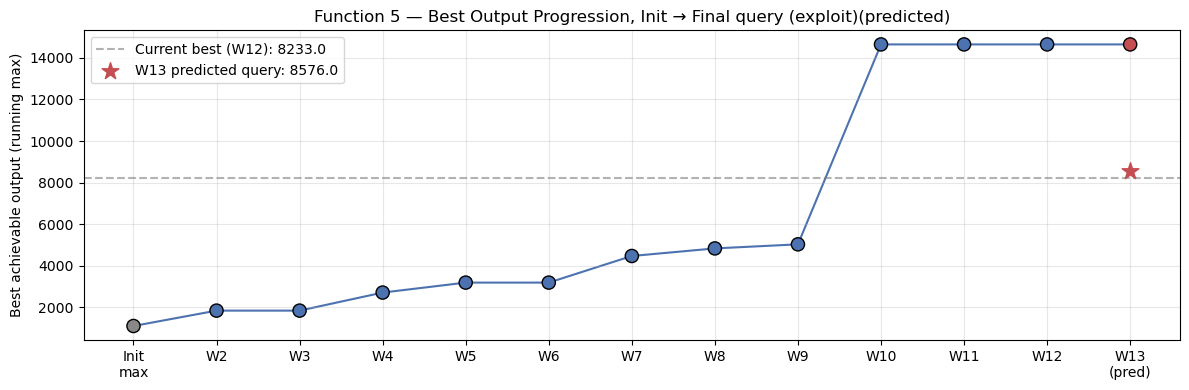

In [28]:
# -------------------------------------------------------------------
# 7. Plot: progression of best-found output across weeks + W13 prediction
# -------------------------------------------------------------------
week_labels = ['Init\nmax'] + [f'W{w}' for w in range(2, 13)] + ['W13\n(pred)']
week_bests = [f5_outputs.max()]
running_best = f5_outputs.max()
for out in prev_outputs_F5:
    running_best = max(running_best, out)
    week_bests.append(running_best)
week_bests.append(max(running_best, predicted_output_gp_F5))

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#888888'] + ['#4C72B0'] * 11 + ['#C44E52']
ax.plot(week_labels, week_bests, '-o', color='#4C72B0', zorder=1)
ax.scatter(week_labels, week_bests, c=colors, s=90, zorder=2, edgecolor='black')

ax.axhline(CURRENT_BEST_VALID_F5, color='gray', linestyle='--', alpha=0.6,
           label=f'Current best (W12): {CURRENT_BEST_VALID_F5:.1f}')
ax.scatter([week_labels[-1]], [predicted_output_gp_F5], color='#C44E52', s=160,
           zorder=3, marker='*', label=f'W13 predicted query: {predicted_output_gp_F5:.1f}')

ax.set_ylabel('Best achievable output (running max)')
ax.set_title('Function 5 — Best Output Progression, Init → Final query (exploit)(predicted)')
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

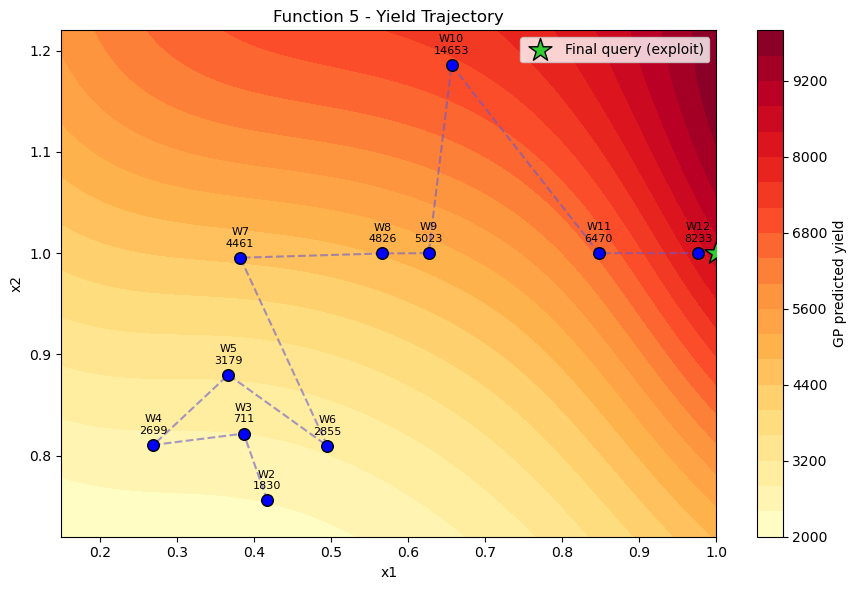

In [29]:
# -------------------------------------------------------------------
# 8. Yield-trajectory contour plot (x1 vs x2 slice, x3=x4 fixed)
#    Style: GP predicted-yield heatmap + historical query path + final query star
# -------------------------------------------------------------------
 
# Fix x3, x4 at the values the trajectory has converged to (1.0, 1.0),
# since nearly every recent query pins those dims at the boundary.
x3_fixed, x4_fixed = 1.0, 1.0
 
# Build a grid over x1, x2
grid_n = 150
x1_range = np.linspace(0.15, 1.0, grid_n)
x2_range = np.linspace(0.72, 1.22, grid_n)   # covers W10's x2=1.186 outlier
X1, X2 = np.meshgrid(x1_range, x2_range)
 
grid_points = np.column_stack([
    X1.ravel(), X2.ravel(),
    np.full(X1.size, x3_fixed), np.full(X1.size, x4_fixed)
])
 
# NOTE: GP was trained on in-bounds [0,1]^4 data only. 
#   Points with x2>1 here are extrapolations purely for visualising the surface near W10 - 
#      treat with caution, same as any GP prediction outside its training envelope.
grid_pred_log = gp_F5.predict(grid_points)
grid_pred = np.expm1(grid_pred_log).reshape(X1.shape)
 
# Build the full labelled trajectory: initial-best -> W2..W12 -> W13 (predicted)
traj_labels = ['W2', 'W3', 'W4', 'W5', 'W6', 'W7', 'W8', 'W9', 'W10', 'W11', 'W12']
traj_points = prev_queries_F5.copy()
traj_outputs = prev_outputs_F5.copy()
 
fig, ax = plt.subplots(figsize=(9, 6))
contour = ax.contourf(X1, X2, grid_pred, levels=25, cmap='YlOrRd')
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('GP predicted yield')
 
# Trajectory line + points
ax.plot(traj_points[:, 0], traj_points[:, 1], '--', color='slateblue', alpha=0.6, zorder=2)
ax.scatter(traj_points[:, 0], traj_points[:, 1], color='blue', edgecolor='black',
           s=70, zorder=3)
 
for label, pt, out in zip(traj_labels, traj_points, traj_outputs):
    ax.annotate(f'{label}\n{out:.0f}', (pt[0], pt[1]),
                textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=8)
 
# Final W13 predicted query as a star
ax.scatter([query_F5[0]], [query_F5[1]], color='limegreen',
           marker='*', s=300, edgecolor='black', zorder=4, label='Final query (exploit)')
 
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('Function 5 - Yield Trajectory')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Function 6 A cake recipe, 5D array, 20 original samples - Week 13

In [30]:
# =============================================================================
# Function 6 A cake recipe, 5D array, 20 original samples
# =============================================================================
# Previous weeks
# W3: ARD GP + EI (ξ = 0.05) over a mixed candidate pool consisting of uniform random samples, 
#     Latin Hypercube Sampling (LHS), and perturbations around the top five recipes.
# W4: GP with ARD Matérn + EI (ξ = 0.02)
# W5: RF surrogate (200 trees); acquisition via Thompson sampling 
#     using a single randomly selected decision tree rather than the ensemble mean
# W6: Random Forest (500 trees); Maximin LHS candidate design; Full-ensemble UCB
# W7: Random Forest Max depth = 5 (new); UCB κ = 1.5; the first explicit regularisation of the RF model
# W8: Hybrid GP + RF (inverse-RMSE weighted blend) + EI with multi-restart L-BFGS-B optimization
# W9: Random Forest surrogate with SHAP explainability; Feature importance explanations influence future search direction
# W10: Two-stage LHS (global + local refinement) scored by GP (isotropic Matérn) + UCB (κ = 2.5); SVR fit but not used for acquisition.
# W11: ARD GP → RF/Thompson → hybrid GP+RF → two-stage LHS refinement, 
#   SHAP explainability directly shaped later search direction; hybrid blending balanced surrogate weaknesses
# W12: Bootstrap ensemble (n=300) of SVR, hyperparameters via GridSearchCV; bootstrap σ calibrated against LOO residuals
#   EI (ξ=0.01) over 2-stage LHS pool (global → local refine around top 50), grid-searched C/γ/ε, calibration factor, ξ=0.01

print("\n" + "=" * 60)
print("Function 6 - Week 13 - Final")
print("=" * 60)

f6_inputs  = np.load('initial_data/function_6/initial_inputs.npy')
f6_outputs = np.load('initial_data/function_6/initial_outputs.npy')

prev_queries_F6 = np.array([
    [0.939456, 0.643603, 0.531941, 1.031640, 0.012391],              # W2 
    [0.463219, 0.306404, 0.635240, 0.999844, 0.015672],              # W3 (second best)
    [0.344063, 0.007363, 0.627449, 0.999999, 0.004891],              # W4
    [0.611853, 0.139494, 0.292145, 0.366362, 0.456070],              # W5
    [0.362372, 0.287752, 0.659391, 0.946547, 0.011897],              # W6 
    [0.119239, 0.206322, 0.998767, 0.816254, 0.063518],              # W7 
    [0.471908, 0.343816, 1.000000, 0.988610, 0.154640],              # W8 
    [0.471060, 0.378037, 0.568185, 0.870856, 0.026973],              # W9 (max, best overall)
    [0.317166, 0.547049, 0.105786, 1.000000, 0.002390],              # W10
    [0.377923, 0.149075, 0.975196, 0.121707, 0.000000],              # W11
    [0.252982, 0.423855, 0.481603, 0.980599, 0.000000],              # W12
])
prev_outputs_F6 = np.array([-1.241946,         # W2 (fail)
                            -0.352945,         # W3 (above initial best, second best)
                            -0.837300,         # W4 (fail)
                            -1.468430,         # W5 (fail)
                            -0.454581,         # W6 (above initial best)
                            -0.859304,         # W7 (fail)
                            -0.650775,         # W8 (above initial best)
                            -0.338381,         # W9 (above initial best, max, best overall)
                            -1.088831,         # W10 (fail)
                            -1.320646,         # W11 (fail)
                            -0.745697,         # W12 (fail)
                           ])

all_inputs_F6  = np.vstack([f6_inputs, prev_queries_F6])
all_outputs_F6 = np.hstack([f6_outputs, prev_outputs_F6])

max_idx_F6 = np.argmax(all_outputs_F6)
max_F6 = all_outputs_F6[max_idx_F6]
print(f"Total points: {len(all_outputs_F6)}")
print(f"Current max: {max_F6:.6e} at {all_inputs_F6[max_idx_F6]}")
print("Aim: maximise the output, apply pure exploitation.")


Function 6 - Week 13 - Final
Total points: 31
Current max: -3.383810e-01 at [0.47106  0.378037 0.568185 0.870856 0.026973]
Aim: maximise the output, apply pure exploitation.


In [31]:
# =============================================================================
# Surrogate: ARD Matern GP fit on the full 31-point history
# =============================================================================
bounds_F6 = [(0.0, 1.0)] * 5
X_F6 = np.clip(all_inputs_F6, 0.0, 1.0)   # domain is [0,1]^5; a couple of weekly
                                           # queries drifted a hair past 1.0
y_F6 = all_outputs_F6

kernel_F6 = (ConstantKernel(1.0, (1e-2, 1e3))
             * Matern(length_scale=np.ones(5), length_scale_bounds=(1e-2, 1e2), nu=2.5)
             + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e-1)))

gp_F6 = GaussianProcessRegressor(kernel=kernel_F6, normalize_y=True,
                                  n_restarts_optimizer=10, random_state=0)
gp_F6.fit(X_F6, y_F6)

print("\nFitted ARD length scales (dims 1-5):",
      np.round(gp_F6.kernel_.k1.k2.length_scale, 4))


Fitted ARD length scales (dims 1-5): [0.7869 0.7975 1.2735 1.337  1.8309]


In [32]:
# --- Pure exploitation objective: predicted mean ONLY, no exploration bonus -
def neg_mean_F6(x):
    x = np.clip(x, 0.0, 1.0).reshape(1, -1)
    mu = gp_F6.predict(x)
    return -mu[0]

# Multi-restart local search seeded at the best observed points 
#    (and a few random restarts) so we exploit the model's optimum near what has already worked well, rather than exploring blindly.

order_F6 = np.argsort(all_outputs_F6)[::-1]
seeds_F6 = list(all_inputs_F6[order_F6[:5]])
rng_F6 = np.random.default_rng(0)
seeds_F6 += [rng_F6.uniform(0, 1, 5) for _ in range(10)]

best_x_F6, best_mu_F6 = None, -np.inf
for x0 in seeds_F6:
    x0c = np.clip(x0, 0.0, 1.0)
    res = minimize(neg_mean_F6, x0c, method='L-BFGS-B', bounds=bounds_F6)
    mu = -res.fun
    if mu > best_mu_F6:
        best_mu_F6, best_x_F6 = mu, res.x

query_F6 = np.clip(best_x_F6, 0.0, 1.0)

print("\n" + "=" * 60)
print("W13 (final) predicted query - pure exploitation")
print("=" * 60)
print(f"Next query F6: {format_query(query_F6)}")
print(f"GP predicted mean at this point: {best_mu_F6:.6e}")
mu_at_query_F6, std_at_query_F6 = gp_F6.predict(query_F6.reshape(1, -1), return_std=True)
print(f"GP predicted std  at this point: {std_at_query_F6[0]:.6e}")
print(f"Current best observed output:     {max_F6:.6e}")
print(f"Predicted improvement:            {best_mu_F6 - max_F6:.6e}")


W13 (final) predicted query - pure exploitation
Next query F6: [0.519654-0.316562-0.598493-0.870191-0.      ]
GP predicted mean at this point: -2.978454e-01
GP predicted std  at this point: 3.043405e-02
Current best observed output:     -3.383810e-01
Predicted improvement:            4.053561e-02


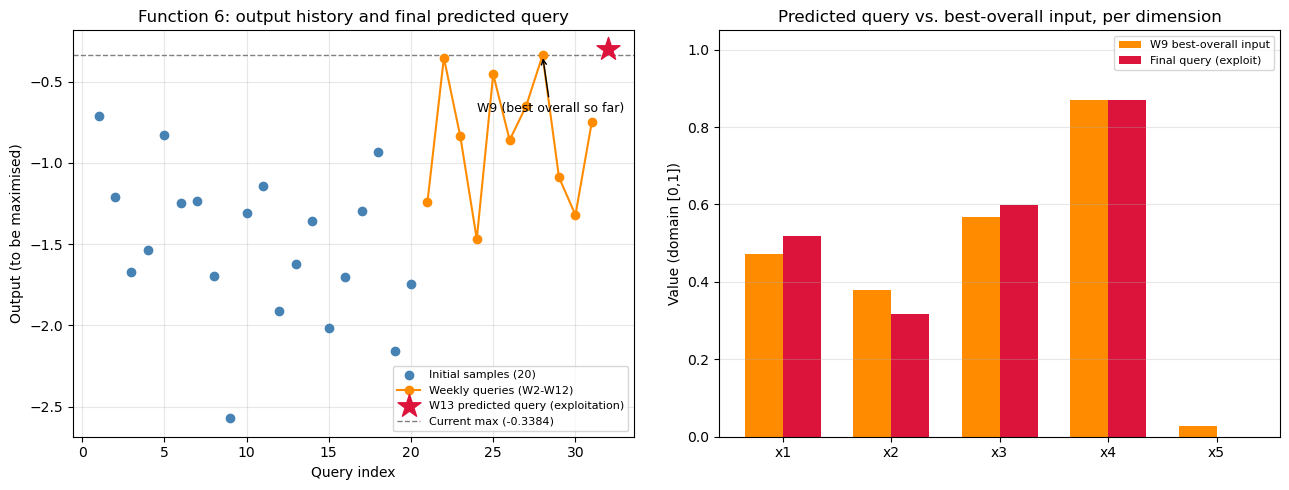

In [33]:
# =============================================================================
# Plot: history of all queries (in output order) + final W13 predicted query
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: output trajectory (initial samples, then weekly queries, then W13 pred)
ax = axes[0]
n_init = len(f6_outputs)
x_init = np.arange(1, n_init + 1)
x_weekly = np.arange(n_init + 1, n_init + 1 + len(prev_outputs_F6))
x_w13 = n_init + 1 + len(prev_outputs_F6)

ax.scatter(x_init, f6_outputs, color='steelblue', label='Initial samples (20)', zorder=3)
ax.plot(x_weekly, prev_outputs_F6, 'o-', color='darkorange', label='Weekly queries (W2-W12)', zorder=3)
ax.scatter([x_w13], [best_mu_F6], color='crimson', marker='*', s=300,
           label='W13 predicted query (exploitation)', zorder=5)
ax.axhline(max_F6, color='gray', linestyle='--', linewidth=1, label=f'Current max ({max_F6:.4f})')

# label the running max / best-overall point (W9)
best_overall_x = n_init + 1 + int(np.where(prev_outputs_F6 == max_F6)[0][0])
ax.annotate('W9 (best overall so far)', xy=(best_overall_x, max_F6),
            xytext=(best_overall_x - 4, max_F6 - 0.35),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

ax.set_xlabel('Query index')
ax.set_ylabel('Output (to be maximised)')
ax.set_title('Function 6: output history and final predicted query')
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.3)

# Right: predicted query vs. current best-overall input, per dimension
ax2 = axes[1]
dims = np.arange(1, 6)
w9_point = prev_queries_F6[7]  # W9, best overall
width = 0.35
ax2.bar(dims - width/2, w9_point, width, label='W9 best-overall input', color='darkorange')
ax2.bar(dims + width/2, query_F6, width, label='Final query (exploit)', color='crimson')
ax2.set_xticks(dims)
ax2.set_xticklabels([f'x{d}' for d in dims])
ax2.set_ylim(0, 1.05)
ax2.set_ylabel('Value (domain [0,1])')
ax2.set_title('Predicted query vs. best-overall input, per dimension')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

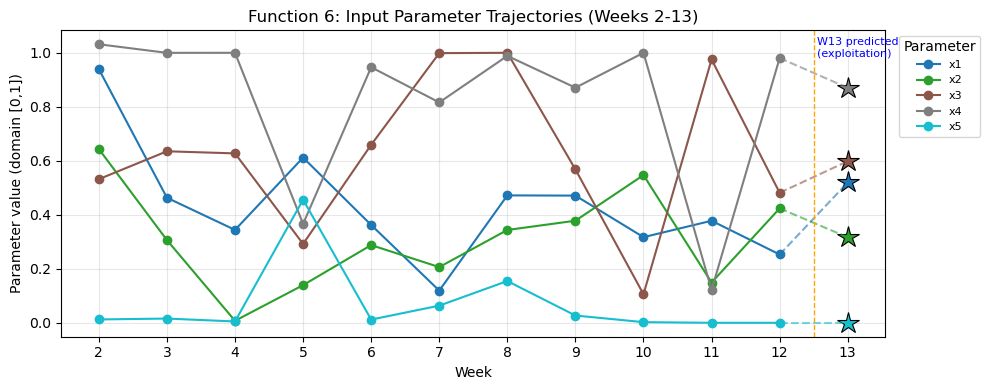

In [34]:
# Weeks 2-12 queries + the W13 predicted query
weeks = np.arange(2, 14)  # W2 ... W13
all_queries_F6 = np.vstack([prev_queries_F6, query_F6])  # (12, 5)

param_labels = ['x1', 'x2', 'x3', 'x4', 'x5']
colors = plt.cm.tab10(np.linspace(0, 1, 5))

fig, ax = plt.subplots(figsize=(10, 4))

for d in range(5):
    ax.plot(weeks[:-1], all_queries_F6[:-1, d], 'o-', color=colors[d],
             label=param_labels[d])
    # highlight the W13 predicted point distinctly
    ax.plot(weeks[-1], all_queries_F6[-1, d], '*', color=colors[d],
             markersize=16, markeredgecolor='black', markeredgewidth=0.8)

# connect last real week (W12) to predicted W13 with a dashed line
for d in range(5):
    ax.plot(weeks[-2:], all_queries_F6[-2:, d], '--', color=colors[d], alpha=0.6)

ax.axvline(12.5, color='orange', linestyle='--', linewidth=1)
ax.text(12.55, ax.get_ylim()[1]*0.91, 'W13 predicted\n(exploitation)',
        fontsize=8, color='blue')

ax.set_xlabel('Week')
ax.set_ylabel('Parameter value (domain [0,1])')
ax.set_title('Function 6: Input Parameter Trajectories (Weeks 2-13)')
ax.set_xticks(weeks)
ax.legend(title='Parameter', fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Function 7, Unspecified field, 6D array, 30 original samples - Week 13

In [35]:
# =============================================================================
# Function 7, Unspecified field, 6D array, 30 original samples
# =============================================================================
# Previous weeks
# W3: Strong exploitation vis Random Forest + SHAP identifies influential variables and preferred directions
# W4: GP EI (on log1p outputs, ξ = 0.01) + MLP regressor (50/50 blend)
# W5: Two-stage approach: RBF interpolator (multiquadric kernel) scores the full candidate set, 
#     then RF re-ranks the top 1,000 candidates
# W6: RF (importance) → ARD GP; Importance-driven subspace narrowing; UCB, multi-start L-BFGS-B
# W7: Two Random Forests → subspace → GP + UCB; Subspace bounds; UCB κ = 2
#     RF-based filtering isolated the dominant HP1 region before GP optimisation
# W8: Two-stage RF filtering (full RF → filtered RF) → GP + UCB (κ = 1.5)
# W9: Dataset filtering before Random Forest optimisation; Reshaping the optimisation landscape through adaptive data selection
# W10: Two-stage RF filtering (100k → 10k → 1k) → GP (sqrt(Y), Matérn + DotProduct) with custom EI computed on the original output scale.
# W11: RF+SHAP exploitation → two-stage RF filtering → subspace narrowing → progressively tighter candidate funnels (100k → 10k → 1k)
# W12: Bootstrap ensemble (n=200) of SVR (manually set C=10, γ=0.5, ε=0.01); selected over RF/GP-residual pipeline via LOOCV comparison
#      Check EI (ξ=0.15, set from LOO error scale) over blended pool (tight/medium local + HP1 subspace + global)
#      C=10, γ=0.5, ε=0.01, ξ=0.15, pool radii 0.08/0.15

print("\n" + "=" * 60)
print("Function 7 - Week 13 - Final")
print("=" * 60)

f7_inputs  = np.load('initial_data/function_7/initial_inputs.npy')
f7_outputs = np.load('initial_data/function_7/initial_outputs.npy')

prev_queries_F7 = np.array([
    [0.079933, 0.633654, 0.734486, 0.864915, 0.103811, 0.933346],    # W2
    [0.020000, 0.229276, 0.478532, 0.247457, 0.365999, 0.737383],    # W3
    [0.012357, 0.162903, 0.399853, 0.082758, 0.249752, 0.923732],    # W4
    [0.042283, 0.348468, 0.793617, 0.259525, 0.456849, 0.822122],    # W5
    [0.020000, 0.084621, 0.685565, 0.148317, 0.347709, 0.669559],    # W6
    [0.063339, 0.123643, 0.074385, 0.373415, 0.318790, 0.765081],    # W7
    [0.002711, 0.256031, 0.238702, 0.111803, 0.341715, 0.769368],    # W8
    [0.057264, 0.054996, 0.341841, 0.256882, 0.307001, 0.720016],    # W9 (second best)
    [0.059517, 0.056546, 0.864985, 0.258438, 0.352116, 0.678089],    # W10
    [0.000000, 0.058944, 0.407235, 0.285037, 0.339090, 0.712563],    # W11
    [0.029986, 0.112119, 0.405753, 0.285528, 0.341381, 0.694030],    # W12 (max, best overall)
])
prev_outputs_F7 = np.array([0.59279,                  # W2 (fail)
                            2.59480,                  # W3 (above initial max)
                            1.08804,                  # W4 (fail)
                            1.31103,                  # W5 (fail)
                            2.130313,                 # W6 (above initial max)
                            2.06359,                  # W7 (above initial max)
                            1.642928,                 # W8 (above initial max)
                            2.74921,                  # W9 (above initial max, second best)
                            1.76236,                  # W10 (above initial max)
                            2.62703,                  # W11 (above initial max)
                            2.83491,                  # W12 (above initial max, max, best overall)
                           ])

all_inputs_F7  = np.vstack([f7_inputs, prev_queries_F7])
all_outputs_F7 = np.hstack([f7_outputs, prev_outputs_F7])

max_idx_F7 = np.argmax(all_outputs_F7)
max_F7 = all_outputs_F7[max_idx_F7]
print(f"Total points: {len(all_outputs_F7)}")
print(f"Current max: {max_F7:.6e} at {all_inputs_F7[max_idx_F7]}")
print("Aim: maximise the output, apply pure exploitation.")


Function 7 - Week 13 - Final
Total points: 41
Current max: 2.834910e+00 at [0.029986 0.112119 0.405753 0.285528 0.341381 0.69403 ]
Aim: maximise the output, apply pure exploitation.


In [36]:
best_x_F7 = all_inputs_F7[max_idx_F7].copy()
best_y_F7 = max_F7

In [37]:
# =============================================================================
# W13 Final: Pure exploitation.
# Continue with the W12-selected model family (bootstrap SVR ensemble),
# compare it against RF and a near-interpolating GP (Matern, small fixed alpha, no learned noise term) 
#     so the surrogate reproduces observed values closely --
#     this matters for exploitation, since we want to trust local gradients around the incumbent
#     rather than smoothing everything toward the dataset mean. Select via LOOCV on the full 41-point dataset.
# =============================================================================

rng_F7 = np.random.default_rng(0)
X_F7 = all_inputs_F7
y_F7 = all_outputs_F7

def bootstrap_svr_predict_F7(X_train, y_train, X_query, n_boot=200, C=10, gamma=0.5, eps=0.01, seed=0):
    rs = np.random.default_rng(seed)
    n = len(X_train)
    preds = np.zeros((n_boot, len(X_query)))
    for b in range(n_boot):
        idx = rs.integers(0, n, n)
        svr = SVR(C=C, gamma=gamma, epsilon=eps)
        svr.fit(X_train[idx], y_train[idx])
        preds[b] = svr.predict(X_query)
    return preds.mean(axis=0), preds.std(axis=0)

loo_F7 = LeaveOneOut()
errs_F7 = {'svr_ens': [], 'rf': [], 'gp': []}
for tr_idx, te_idx in loo_F7.split(X_F7):
    Xtr, Xte = X_F7[tr_idx], X_F7[te_idx]
    ytr, yte = y_F7[tr_idx], y_F7[te_idx]

    mu, _ = bootstrap_svr_predict_F7(Xtr, ytr, Xte, n_boot=60)
    errs_F7['svr_ens'].append((mu[0] - yte[0]) ** 2)

    rf = RandomForestRegressor(n_estimators=300, random_state=0)
    rf.fit(Xtr, ytr)
    errs_F7['rf'].append((rf.predict(Xte)[0] - yte[0]) ** 2)

    kernel_cv = ConstantKernel(1.0) * Matern(length_scale=np.ones(X_F7.shape[1]), nu=2.5)
    gp_cv_F7 = GaussianProcessRegressor(kernel=kernel_cv, alpha=1e-6, normalize_y=True,
                                         n_restarts_optimizer=3, random_state=0)
    gp_cv_F7.fit(Xtr, ytr)
    errs_F7['gp'].append((gp_cv_F7.predict(Xte)[0] - yte[0]) ** 2)

for k, v in errs_F7.items():
    print(f"LOOCV RMSE [{k}] = {np.sqrt(np.mean(v)):.4f}")

best_model_F7 = min(errs_F7, key=lambda k: np.mean(errs_F7[k]))
print(f"Selected model for exploitation: {best_model_F7}")

LOOCV RMSE [svr_ens] = 0.4430
LOOCV RMSE [rf] = 0.4817
LOOCV RMSE [gp] = 0.4182
Selected model for exploitation: gp


In [38]:
# =============================================================================
# Refit the chosen surrogate on the FULL dataset and run pure exploitation:
#    maximise the predicted mean directly (no EI/UCB exploration term), 
#    with a tight trust region around the current best point (multi-start L-BFGS-B)
#    and a global multi-start pass as a safety net.
# =============================================================================
def make_predict_fn_F7():
    if best_model_F7 == 'svr_ens':
        def predict(Xq):
            mu, _ = bootstrap_svr_predict_F7(X_F7, y_F7, np.atleast_2d(Xq), n_boot=200)
            return mu
        return predict
    elif best_model_F7 == 'rf':
        rf = RandomForestRegressor(n_estimators=500, random_state=0).fit(X_F7, y_F7)
        return lambda Xq: rf.predict(np.atleast_2d(Xq))
    else:
        kernel_final = ConstantKernel(1.0) * Matern(length_scale=np.ones(X_F7.shape[1]), nu=2.5)
        gp_final = GaussianProcessRegressor(kernel=kernel_final, alpha=1e-6, normalize_y=True,
                                             n_restarts_optimizer=8, random_state=0).fit(X_F7, y_F7)
        return lambda Xq: gp_final.predict(np.atleast_2d(Xq))

predict_fn_F7 = make_predict_fn_F7()

def neg_pred_F7(x):
    x = np.clip(x, 0.0, 1.0)
    return -predict_fn_F7(x)[0]

# Trust-region local search around the current best
radius_F7 = 0.06
lb_local_F7 = np.clip(best_x_F7 - radius_F7, 0.0, 1.0)
ub_local_F7 = np.clip(best_x_F7 + radius_F7, 0.0, 1.0)
bounds_local_F7 = list(zip(lb_local_F7, ub_local_F7))

n_starts_F7 = 40
starts_F7 = best_x_F7 + rng_F7.normal(scale=radius_F7 / 2, size=(n_starts_F7, len(best_x_F7)))
starts_F7 = np.clip(starts_F7, lb_local_F7, ub_local_F7)
starts_F7[0] = best_x_F7  # always include the incumbent

candidates_F7 = []
for s in starts_F7:
    res = minimize(neg_pred_F7, s, method='L-BFGS-B', bounds=bounds_local_F7)
    candidates_F7.append((res.x, -res.fun))

# Global multi-start safety net (in case the local optimum isn't global)
n_global_F7 = 20
global_starts_F7 = rng_F7.uniform(0.0, 1.0, size=(n_global_F7, len(best_x_F7)))
bounds_global_F7 = [(0.0, 1.0)] * len(best_x_F7)
for s in global_starts_F7:
    res = minimize(neg_pred_F7, s, method='L-BFGS-B', bounds=bounds_global_F7)
    candidates_F7.append((res.x, -res.fun))

# Pick the best candidate
candidates_F7.sort(key=lambda t: -t[1])
query_F7, predicted_value_F7 = candidates_F7[0]
query_F7 = np.clip(query_F7, 0.0, 1.0)

print("\n" + "=" * 60)
print("W13 (final) predicted query - pure exploitation")
print("=" * 60)
print(f"Next query F7 : {format_query(query_F7)}")
print(f"Predicted output: {predicted_value_F7:.6f}")
print(f"Current max     : {best_y_F7:.6f}")
print(f"Predicted gain  : {predicted_value_F7 - best_y_F7:+.6f}")


W13 (final) predicted query - pure exploitation
Next query F7 : [0.07453 -0.133346-0.397044-0.268743-0.33635 -0.68205 ]
Predicted output: 2.919530
Current max     : 2.834910
Predicted gain  : +0.084620


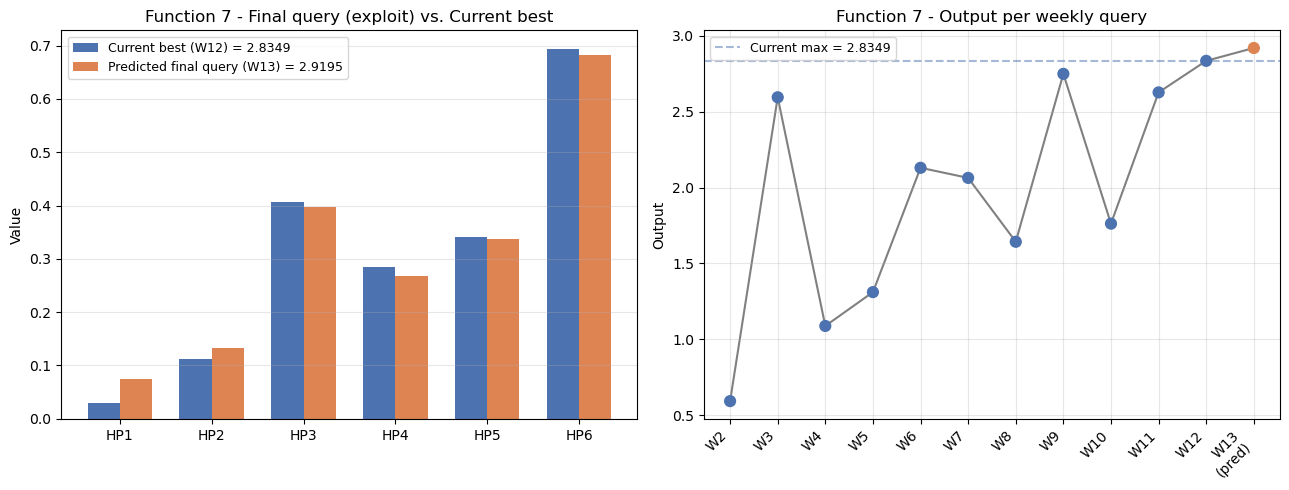

In [39]:
# =============================================================================
# Plot: predicted W13 query vs. current best (W12) query per dimension,
# plus the output trajectory across all weekly queries including W13.
# =============================================================================

dims = [f"HP{i+1}" for i in range(X_F7.shape[1])]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: per-dimension comparison
x_pos = np.arange(len(dims))
width = 0.35
axes[0].bar(x_pos - width/2, best_x_F7, width, label=f"Current best (W12) = {best_y_F7:.4f}", color="#4C72B0")
axes[0].bar(x_pos + width/2, query_F7, width, label=f"Predicted final query (W13) = {predicted_value_F7:.4f}", color="#DD8452")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(dims)
axes[0].set_ylabel("Value")
axes[0].set_title("Function 7 - Final query (exploit) vs. Current best")
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# Right: output trajectory across weeks, with predicted W13 point
week_labels = ["W2","W3","W4","W5","W6","W7","W8","W9","W10","W11","W12","W13\n(pred)"]
week_outputs = list(prev_outputs_F7) + [predicted_value_F7]
colors = ["#4C72B0"] * len(prev_outputs_F7) + ["#DD8452"]
axes[1].plot(week_labels, week_outputs, "-o", color="grey", zorder=1)
axes[1].scatter(week_labels, week_outputs, c=colors, zorder=2, s=60)
axes[1].axhline(best_y_F7, color="#4C72B0", linestyle="--", alpha=0.5, label=f"Current max = {best_y_F7:.4f}")
axes[1].set_ylabel("Output")
axes[1].set_title("Function 7 - Output per weekly query")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

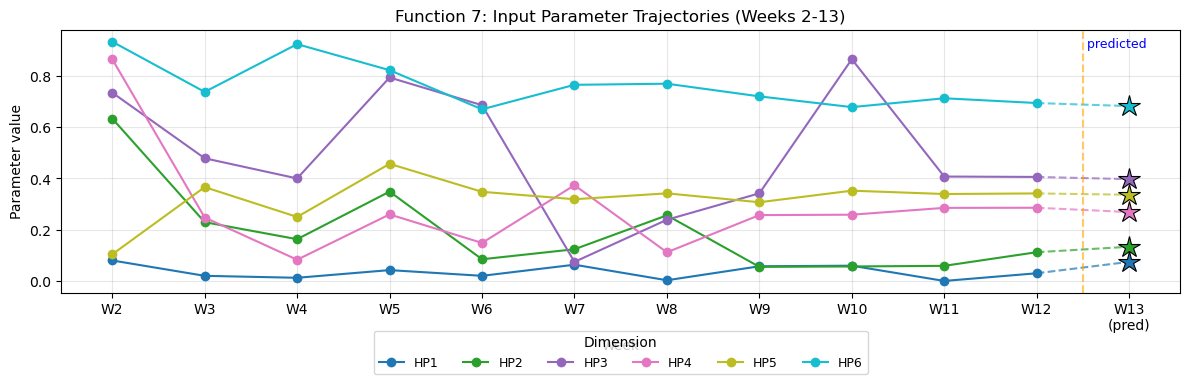

In [40]:
# W13 predicted next query (pure exploitation result from the surrogate search above)
all_queries_F7 = np.vstack([prev_queries_F7, query_F7])
weeks = list(range(2, 14))  # W2 .. W13
dim_labels = [f"HP{i+1}" for i in range(all_queries_F7.shape[1])]

fig, ax = plt.subplots(figsize=(12, 4))
colors = plt.cm.tab10(np.linspace(0, 1, all_queries_F7.shape[1]))

for d in range(all_queries_F7.shape[1]):
    # solid line for observed weeks (W2-W12)
    ax.plot(weeks[:-1], all_queries_F7[:-1, d], "-o", color=colors[d], label=dim_labels[d])
    # dashed segment into the predicted W13 point
    ax.plot(weeks[-2:], all_queries_F7[-2:, d], "--", color=colors[d], alpha=0.7)
    ax.plot(weeks[-1], all_queries_F7[-1, d], "*", color=colors[d], markersize=16,
            markeredgecolor="black", markeredgewidth=0.8, zorder=5)

ax.axvline(weeks[-1] - 0.5, color="orange", linestyle="--", alpha=0.6)
ax.text(weeks[-1] - 0.5, ax.get_ylim()[1] * 0.97, " predicted", fontsize=9, color="blue", ha="left", va="top")

ax.set_xticks(weeks)
ax.set_xticklabels([f"W{w}" if w < 13 else "W13\n(pred)" for w in weeks])
ax.set_xlabel("Week")
ax.set_ylabel("Parameter value")
ax.set_title("Function 7: Input Parameter Trajectories (Weeks 2-13)")
ax.legend(title="Dimension", ncol=6, loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Function 8, Unspecified field, 8D array, 40 original samples - Week 13

In [41]:
# =============================================================================
# Function 8, Unspecified field, 8D array, 40 original samples
# =============================================================================
# Previous weeks
# W3: Pipeline (a) combines partial exploration (free dimensions) with strong exploitation (pinned dimensions); 
#     Pipeline (b) is almost entirely exploitation-focused.
# W4: GP (ARD Matérn) UCB (κ = 2.0) + MLP regressor (50/50 blend)
# W5: MC-Dropout MLP (2 hidden layers, dropout active during inference with 50 stochastic forward passes); acquisition = UCB (κ = 3.0)
# W6: Dropout MLP (8→24→24→1); Standard scaling; UCB via MC-dropout uncertainty
# W7: MC-Dropout MLP; Dropout = 0.2; hidden units = 24; UCB κ = 1.7; SHAP-scaled noise; 
#     HAP-informed candidate generation to guide exploration
# W8: MC-Dropout MLP + UCB with adaptive κ (κ_base × calibration ratio)
# W9: NN surrogate with MC dropout uncertainty; learned latent representations and stochastic uncertainty estimates
# W10: MC-Dropout MLP (weighted loss, increased capacity) + LHS candidate pool (50k) + UCB with adaptive κ (from LOO calibration).
# W11: MC-Dropout MLP (hidden=48, dropout=0.25)	UCB, adaptive κ = κ_base(1.7) × calibration ratio
# W12: MC-Dropout MLP (48 hidden, dropout=0.25), weighted MSE loss (5×/10× for high-y points), σ from 100 MC passes; SHAP for interpretability
#      UCB with adaptive κ = κ_base × (LOO error/σ ratio) over 50k LHS candidates
#      hidden=48, dropout=0.25, lr=1e-3, epochs=1500, κ_base=1.0, loss weights 5×/10×
#      κ self-calibrates from a full weighted LOO retraining loop; loss reweighting focuses capacity on rare high-value region

print("\n" + "=" * 60)
print("Function 8 - Week 13 - Final")
print("=" * 60)

f8_inputs  = np.load('initial_data/function_8/initial_inputs.npy')
f8_outputs = np.load('initial_data/function_8/initial_outputs.npy')

prev_queries_F8 = np.array([
    [0.034736, 0.033935, 0.577646, 0.735810, 0.807192, 0.026536, 0.72178, 0.629862],     #W2
    [0.019981, 0.000000, 0.999999, 0.000000, 0.448273, 0.855526, 0.446219, 0.931836],    #W3
    [0.035148, 0.000000, 0.018976, 0.000000, 0.999999, 0.361194, 0.007310, 0.000000],    #W4
    [0.040725, 0.748531, 0.178080, 0.981020, 0.988831, 0.993927, 0.013038, 0.216952],    #W5
    [0.060495, 0.027090, 0.006185, 0.132068, 0.160719, 0.354431, 0.001361, 0.931902],    #W6
    [0.000000, 0.009147, 0.046571, 0.113147, 0.150211, 0.340739, 0.038068, 0.928497],    #W7
    [0.007786, 0.000000, 0.000000, 0.000000, 0.999999, 0.368073, 0.022080, 0.018153],    #W8
    [0.000000, 0.000000, 0.001701, 0.357817, 0.997203, 0.357817, 0.357817, 0.002035],    #W9
    [0.071358, 0.056561, 0.038275, 0.129888, 0.740838, 0.572688, 0.045918, 0.708294],    #W10 (max, best overall)
    [0.092021, 0.060978, 0.018488, 0.360040, 0.924657, 0.902361, 0.221460, 0.926437],    #W11
    [0.003289, 0.061686, 0.133145, 0.023473, 0.739835, 0.834983, 0.001894, 0.599951],    #W12 (second best)
])
prev_outputs_F8 = np.array([8.26488,                    #W2 (fail)
                            7.35099,                    #W3 (fail)
                            9.76008,                    #W4 (above initial max)
                            8.590830,                   #W5 (fail)
                            9.619999,                   #W6 (above initial max)
                            9.638210,                   #W7 (above initial max)
                            9.752723,                   #W8 (above initial max)
                            9.730200,                   #W9 (above initial max)
                            9.90829,                    #W10 (above initial max, max, best overall)
                            9.729284,                   #W11 (above initial max)
                            9.764940,                   #W12 (above initial max, second best)
                           ])

all_inputs_F8  = np.vstack([f8_inputs, prev_queries_F8])
all_outputs_F8 = np.hstack([f8_outputs, prev_outputs_F8])

max_idx_F8 = np.argmax(all_outputs_F8)
best_x_F8 = all_inputs_F8[max_idx_F8]
best_y_F8 = all_outputs_F8[max_idx_F8]

print(f"Total points: {len(all_outputs_F8)}")
print(f"Current max: {best_y_F8:.6e} at {best_x_F8}")
print("Aim: maximise the output, apply PURE EXPLOITATION (final week).")


Function 8 - Week 13 - Final
Total points: 51
Current max: 9.908290e+00 at [0.071358 0.056561 0.038275 0.129888 0.740838 0.572688 0.045918 0.708294]
Aim: maximise the output, apply PURE EXPLOITATION (final week).


In [42]:
# =============================================================================
# Surrogate: GP with ARD Matern kernel (consistent with earlier-week surrogate family), fit on ALL 51 points.
#  No acquisition exploration term is used this week ->  directly maximise the GP posterior MEAN (mu(x)), i.e. kappa = 0.
# =============================================================================

X_F8 = all_inputs_F8
y_F8 = all_outputs_F8

y_mean_F8, y_std_F8 = y_F8.mean(), y_F8.std()
y_norm_F8 = (y_F8 - y_mean_F8) / y_std_F8

kernel_F8 = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(
    length_scale=np.ones(X_F8.shape[1]),
    length_scale_bounds=(1e-2, 1e2),
    nu=2.5,
) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 1e-1))

gp_F8 = GaussianProcessRegressor(
    kernel=kernel_F8,
    normalize_y=False,
    n_restarts_optimizer=8,
    random_state=0,
)
gp_F8.fit(X_F8, y_norm_F8)

def neg_mean_F8(x):
    x = np.clip(x, 0.0, 1.0).reshape(1, -1)
    mu, _ = gp_F8.predict(x, return_std=True)
    return -mu[0]

# Pure exploitation -> search in a local TRUST REGION around the current best point rather than the full unit cube. 
# This avoids extrapolating the GP mean to unexplored corners of the box
#  (spuriously "optimistic" mean with little support) and stays true to an exploitation-only strategy.

trust_radius_F8 = 0.15
bounds_F8 = [
    (max(0.0, best_x_F8[d] - trust_radius_F8), min(1.0, best_x_F8[d] + trust_radius_F8))
    for d in range(X_F8.shape[1])
]

In [43]:
# -----------------------------------------------------------------------
# Pure exploitation local search: multi-start L-BFGS-B on the GP mean, started from
#   (a) the current best point and small perturbations of it (trust-region-style refinement), and 
#   (b) the next-best historical points, to squeeze out any remaining local improvement near the known optimum.
# -----------------------------------------------------------------------
top_k_F8 = 5
top_idx_F8 = np.argsort(all_outputs_F8)[::-1][:top_k_F8]
starts_F8 = [all_inputs_F8[i] for i in top_idx_F8]

rng_F8 = np.random.default_rng(0)
for _ in range(20):
    jitter = rng_F8.normal(scale=0.03, size=X_F8.shape[1])
    starts_F8.append(np.clip(best_x_F8 + jitter, 0.0, 1.0))

lo_F8 = np.array([b[0] for b in bounds_F8])
hi_F8 = np.array([b[1] for b in bounds_F8])

results_F8 = []
for x0 in starts_F8:
    x0 = np.clip(x0, lo_F8, hi_F8)
    res = minimize(neg_mean_F8, x0, method='L-BFGS-B', bounds=bounds_F8)
    results_F8.append((res.fun, res.x))

results_F8.sort(key=lambda r: r[0])
best_pred_norm_F8, query_F8 = results_F8[0]

mu_opt_F8, std_opt_F8 = gp_F8.predict(query_F8.reshape(1, -1), return_std=True)
pred_y_F8 = mu_opt_F8[0] * y_std_F8 + y_mean_F8
pred_std_F8 = std_opt_F8[0] * y_std_F8

query_F8 = np.clip(query_F8, 0.0, 1.0)

print("\n" + "=" * 60)
print("W13 (final) predicted query - pure exploitation)")
print("=" * 60)
print(f"Next query F8 = {format_query(query_F8)}")
print(f"Predicted output: {pred_y_F8:.6f}  (+/- {pred_std_F8:.4f} GP std)")
print(f"Current max was:  {best_y_F8:.6f} at {best_x_F8}")
print(f"Predicted improvement: {pred_y_F8 - best_y_F8:+.6f}")


W13 (final) predicted query - pure exploitation)
Next query F8 = [0.10955 -0.16902 -0.139072-0.163982-0.824916-0.495502-0.186827-0.858294]
Predicted output: 10.005407  (+/- 0.0284 GP std)
Current max was:  9.908290 at [0.071358 0.056561 0.038275 0.129888 0.740838 0.572688 0.045918 0.708294]
Predicted improvement: +0.097117


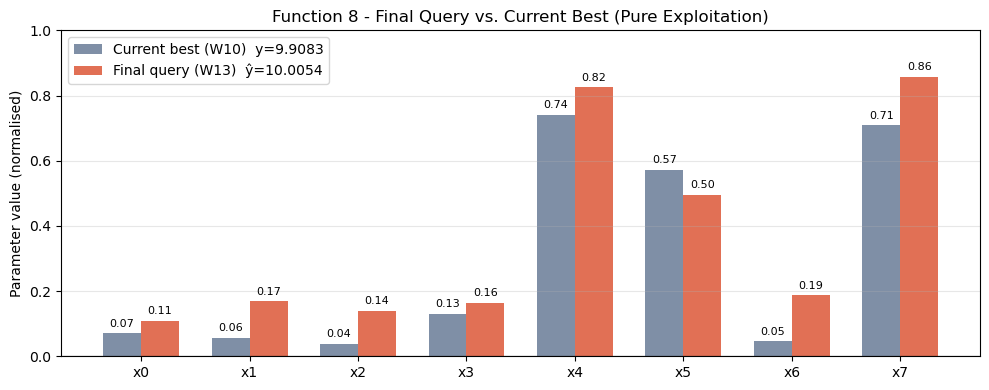

In [44]:
# =============================================================================
# Plot: final predicted query vs. current best query, per dimension
# =============================================================================

dims = [f"x{i}" for i in range(X_F8.shape[1])]
x_vals = np.arange(len(dims))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x_vals - width/2, best_x_F8, width, label=f"Current best (W10)  y={best_y_F8:.4f}", color="#7f8fa6")
ax.bar(x_vals + width/2, query_F8, width, label=f"Final query (W13)  ŷ={pred_y_F8:.4f}", color="#e17055")

ax.set_xticks(x_vals)
ax.set_xticklabels(dims)
ax.set_ylim(0, 1)
ax.set_ylabel("Parameter value (normalised)")
ax.set_title("Function 8 - Final Query vs. Current Best (Pure Exploitation)")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for i, (b, f) in enumerate(zip(best_x_F8, query_F8)):
    ax.text(i - width/2, b + 0.02, f"{b:.2f}", ha="center", fontsize=8)
    ax.text(i + width/2, f + 0.02, f"{f:.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

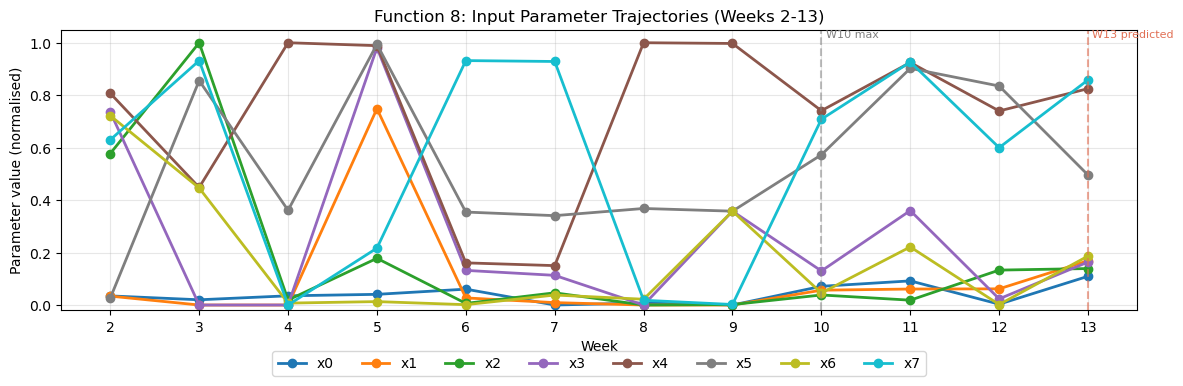

In [45]:
# Weekly queries for Function 8, W2-W12 (actual), W13 = final predicted query
weeks = list(range(2, 14))  # 2..13

all_queries_F8 = np.vstack([prev_queries_F8, query_F8])  # shape (12, 8) -> W2..W13
dims_n = all_queries_F8.shape[1]
colors = plt.cm.tab10(np.linspace(0, 1, dims_n))

fig, ax = plt.subplots(figsize=(12, 4))
for d in range(dims_n):
    ax.plot(weeks, all_queries_F8[:, d], marker='o', linewidth=2,
            color=colors[d], label=f"x{d}")

ax.axvline(10, color='gray', linestyle='--', alpha=0.5)
ax.text(10.05, 1.02, "W10 max", fontsize=8, color='gray')
ax.axvline(13, color='#e17055', linestyle='--', alpha=0.6)
ax.text(13.05, 1.02, "W13 predicted", fontsize=8, color='#e17055')

ax.set_xticks(weeks)
ax.set_xlabel("Week")
ax.set_ylabel("Parameter value (normalised)")
ax.set_ylim(-0.02, 1.05)
ax.set_title("Function 8: Input Parameter Trajectories (Weeks 2-13)")
ax.legend(ncol=8, loc='upper center', bbox_to_anchor=(0.5, -0.12))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary — this week's submissions

Collects the `query_F*` variable set in each section above, so the final submission list is read off one place rather than re-derived by eye from scattered print statements.

In [46]:
submissions = {
    1: query_F1,
    2: query_F2,
    3: query_F3,
    4: query_F4,
    5: query_F5,
    6: query_F6,
    7: query_F7,
    8: query_F8,
}

for fn_id, query in submissions.items():
    print(f"Function {fn_id}: {format_query(query)}")

Function 1: [0.70775 -0.703848]
Function 2: [0.70002 -0.260148]
Function 3: [0.422378-0.269491-0.411072]
Function 4: [0.40142 -0.38321 -0.356729-0.411328]
Function 5: [1.-1.-1.-1.]
Function 6: [0.519654-0.316562-0.598493-0.870191-0.      ]
Function 7: [0.07453 -0.133346-0.397044-0.268743-0.33635 -0.68205 ]
Function 8: [0.10955 -0.16902 -0.139072-0.163982-0.824916-0.495502-0.186827-0.858294]


# Fidelity Metrics (Surrogate Mimicry) evaluation

| Function   | Prediction |   Actual |
| ---------- | ---------: | -------: |
| Function 1 |   1.03E-09 | 9.92E-09 |
| Function 2 |   0.639679 | 0.673566 |
| Function 3 |  -2.28E-02 | -0.03348 |
| Function 4 |   0.499878 | 0.511339 |
| Function 5 |  8575.9543 | 8662.483 |
| Function 6 |  -2.98E-01 | -0.39403 |
| Function 7 |    2.91953 | 3.013542 |
| Function 8 |  10.005407 | 9.991664 |


In [47]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Load data into arrays
data = {
    "Function": [f"Function {i}" for i in range(1, 9)],
    "Prediction": [1.03E-09, 0.639679, -2.28E-02, 0.499878, 8575.9543, -2.98E-01, 2.91953, 10.005407],
    "Actual": [9.92E-09, 0.673566, -0.03348, 0.511339, 8662.483, -0.39403, 3.013542, 9.991664]
}

df = pd.DataFrame(data)
y_pred = df["Prediction"].to_numpy()
y_actual = df["Actual"].to_numpy()

# 2. Compute Fidelity / Error Metrics
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)

# Relative Absolute Error (%)
rae = np.sum(np.abs(y_actual - y_pred)) / np.sum(np.abs(y_actual - np.mean(y_actual))) * 100

print("--- Surrogate Model Fidelity Metrics ---")
print(f"MSE:  {mse:.4e}")
print(f"RMSE: {rmse:.4e}")
print(f"MAE:  {mae:.4e}")
print(f"R2 Score: {r2:.4f}")
print(f"Relative Absolute Error: {rae:.2f}%")

--- Surrogate Model Fidelity Metrics ---
MSE:  9.3590e+02
RMSE: 3.0593e+01
MAE:  1.0849e+01
R2 Score: 0.9999
Relative Absolute Error: 0.57%


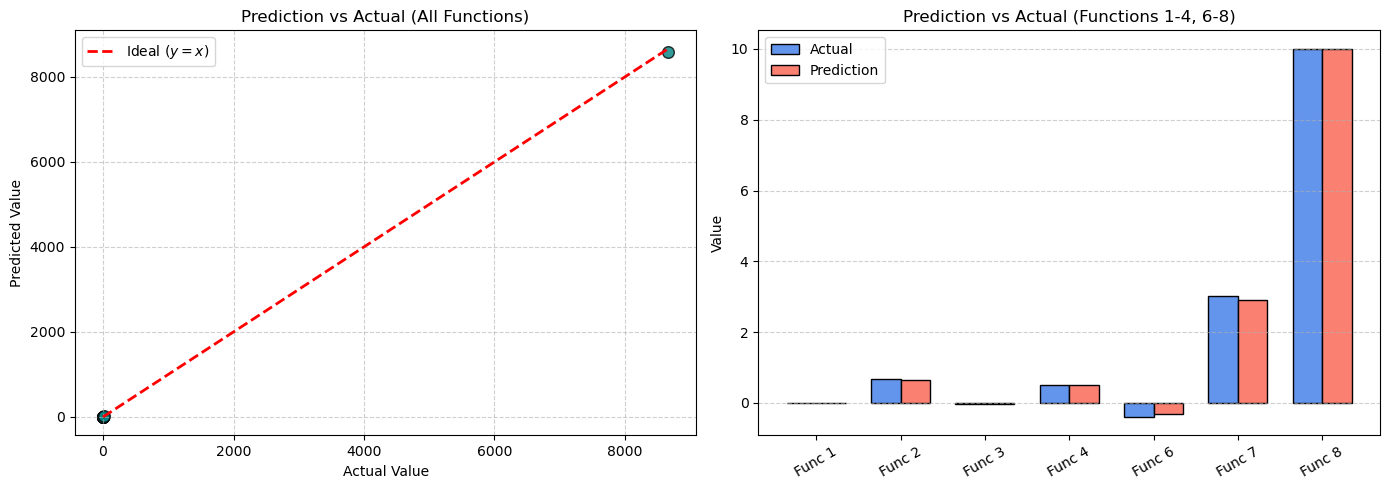

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Setup Figure Layout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: Scatter Plot (All Functions) ---
axes[0].scatter(df['Actual'], df['Prediction'], color='teal', s=70, edgecolor='black', alpha=0.8)
min_val = min(df['Actual'].min(), df['Prediction'].min())
max_val = max(df['Actual'].max(), df['Prediction'].max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal ($y=x$)')
axes[0].set_title('Prediction vs Actual (All Functions)')
axes[0].set_xlabel('Actual Value')
axes[0].set_ylabel('Predicted Value')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Panel 2: Grouped Bar Chart (Excluding Function 5 for Scale Clarity) ---
df_small = df[df['Function'] != 'Function 5']
x = np.arange(len(df_small))
width = 0.35

axes[1].bar(x - width/2, df_small['Actual'], width, label='Actual', color='cornflowerblue', edgecolor='black')
axes[1].bar(x + width/2, df_small['Prediction'], width, label='Prediction', color='salmon', edgecolor='black')
axes[1].set_title('Prediction vs Actual (Functions 1-4, 6-8)')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"Func {i}" for i in [1,2,3,4,6,7,8]], rotation=30)
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6, axis='y')

plt.tight_layout()
plt.show()

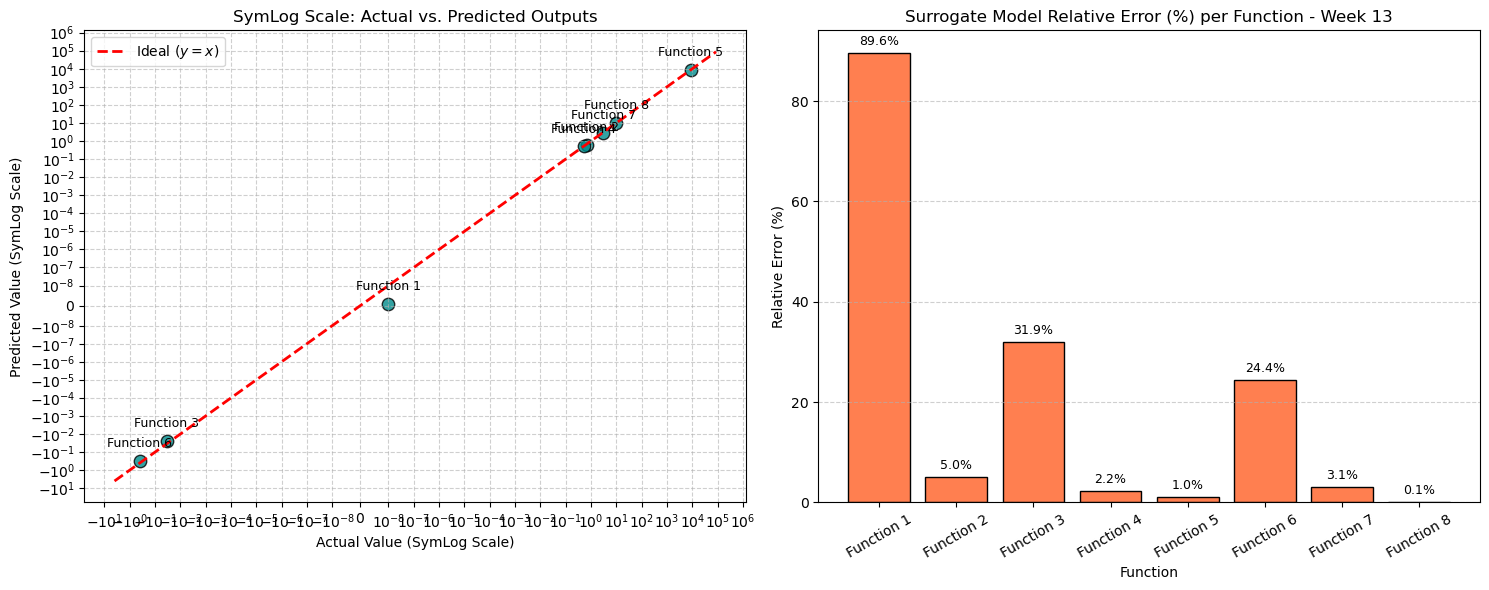

In [49]:
df = pd.DataFrame(data)

# 1. Load data

df = pd.DataFrame(data)

# 2. Compute Relative Error (%)
df['Relative_Error_%'] = np.abs(df['Actual'] - df['Prediction']) / np.abs(df['Actual']) * 100

# 3. Plotting Results
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: SymLog Scale Scatter Plot (Actual vs Prediction)
axes[0].scatter(df['Actual'], df['Prediction'], color='darkcyan', s=80, edgecolor='black', alpha=0.8)
min_val = min(df['Actual'].min(), df['Prediction'].min())
max_val = max(df['Actual'].max(), df['Prediction'].max())

axes[0].plot([min_val*10, max_val*10], [min_val*10, max_val*10], 'r--', lw=2, label='Ideal ($y=x$)')
axes[0].set_xscale('symlog', linthresh=1e-8)
axes[0].set_yscale('symlog', linthresh=1e-8)
axes[0].set_title('SymLog Scale: Actual vs. Predicted Outputs')
axes[0].set_xlabel('Actual Value (SymLog Scale)')
axes[0].set_ylabel('Predicted Value (SymLog Scale)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

for _, row in df.iterrows():
    axes[0].annotate(row['Function'], (row['Actual'], row['Prediction']), 
                     textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

# Panel 2: Relative Error (%) Bar Chart
x_indices = np.arange(len(df['Function']))
bars = axes[1].bar(x_indices, df['Relative_Error_%'], color='coral', edgecolor='black')
axes[1].set_title('Surrogate Model Relative Error (%) per Function - Week 13')
axes[1].set_xlabel('Function')
axes[1].set_ylabel('Relative Error (%)')

# Fix for the UserWarning by setting ticks explicitly first
axes[1].set_xticks(x_indices)
axes[1].set_xticklabels(df['Function'], rotation=30)
axes[1].grid(True, linestyle='--', alpha=0.6, axis='y')

for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.1f}%", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

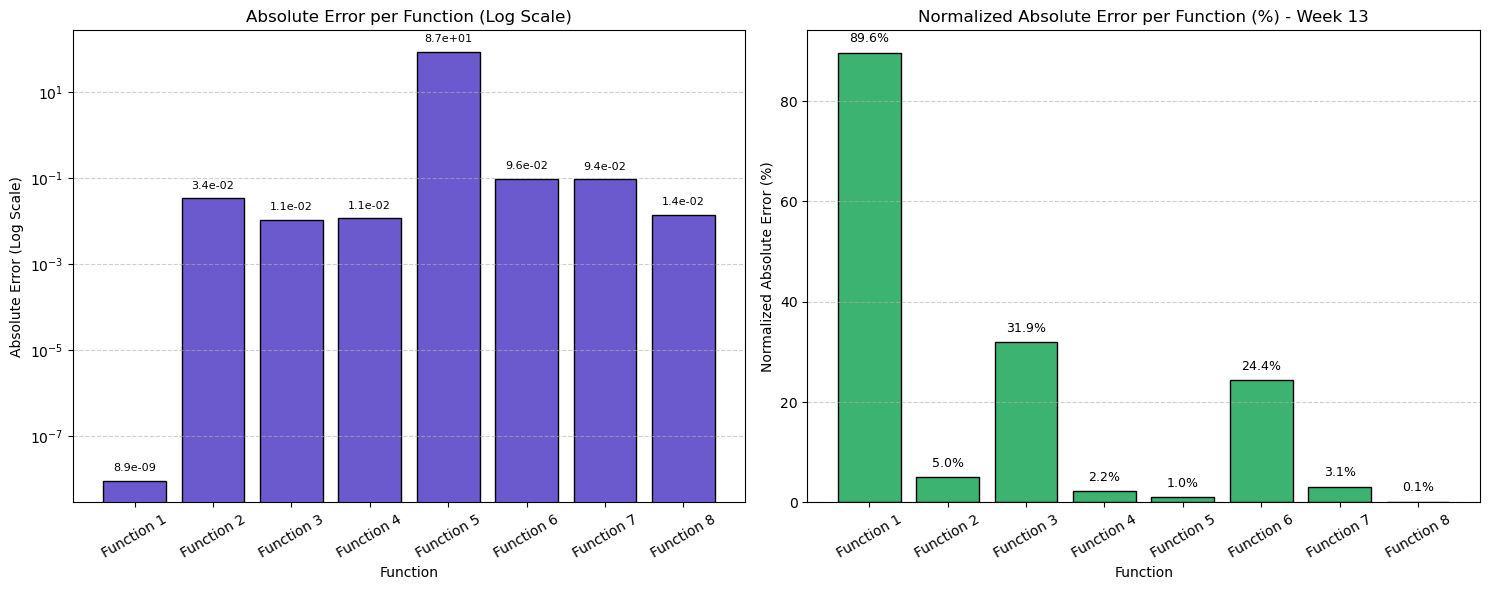

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data

df = pd.DataFrame(data)

# 2. Compute metrics
df['Absolute_Error'] = np.abs(df['Actual'] - df['Prediction'])
df['Normalized_Absolute_Error_%'] = (df['Absolute_Error'] / np.abs(df['Actual'])) * 100

# 3. Plotting Side-by-Side Comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
x_indices = np.arange(len(df['Function']))

# --- Panel 1: Absolute Error per Function (Log Scale) ---
bars1 = axes[0].bar(x_indices, df['Absolute_Error'], color='slateblue', edgecolor='black')
axes[0].set_yscale('log')
axes[0].set_title('Absolute Error per Function (Log Scale)')
axes[0].set_xlabel('Function')
axes[0].set_ylabel('Absolute Error (Log Scale)')
axes[0].set_xticks(x_indices)
axes[0].set_xticklabels(df['Function'], rotation=30)
axes[0].grid(True, linestyle='--', axis='y', alpha=0.6)

for bar in bars1:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2.0, yval * 1.5, f"{yval:.1e}", 
                 ha='center', va='bottom', fontsize=8, rotation=0)

# --- Panel 2: Normalized Absolute Error per Function (%) ---
bars2 = axes[1].bar(x_indices, df['Normalized_Absolute_Error_%'], color='mediumseagreen', edgecolor='black')
axes[1].set_title('Normalized Absolute Error per Function (%) - Week 13')
axes[1].set_xlabel('Function')
axes[1].set_ylabel('Normalized Absolute Error (%)')
axes[1].set_xticks(x_indices)
axes[1].set_xticklabels(df['Function'], rotation=30)
axes[1].grid(True, linestyle='--', axis='y', alpha=0.6)

for bar in bars2:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f"{yval:.1f}%", 
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()